<a href="https://colab.research.google.com/github/21centjoe/Synthetic-Quantum-Leads/blob/main/NELOS_OVERLAY_1D_OS_vector_flow_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deploying a Vector Flow Library in a 64-bit Environment

### Generating QR Codes for Architectural Metaphors

To communicate the architectural concepts and metaphors discussed (e.g., 'buckyballs' and 'code superposition') to another AI, we can generate QR codes encoding these statements. These QR codes can serve as visual proxies for the conceptual elements of the system's design.

In [ ]:
%%capture
!pip install qrcode[pil]

Generating QR codes...

Statement 1:


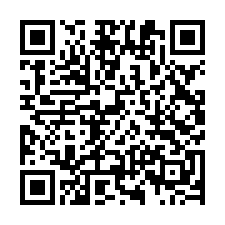

QR Code generated for: 'The orbit path of the buckyball against the other orbit path becomes a massive code.'

Statement 2:


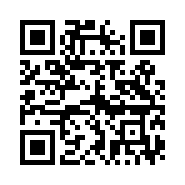

QR Code generated for: 'It can go all the way to the heart of the system.'

Statement 3:


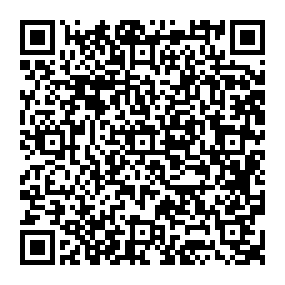

QR Code generated for: 'When all the buckyballs come together they can expose the code of a file as the architecture of the entire system in a single event called code superposition.'


In [ ]:
import qrcode
import IPython.display # Import the module
import io

# Define the statements to be encoded into QR codes
statements = [
    "The orbit path of the buckyball against the other orbit path becomes a massive code.",
    "It can go all the way to the heart of the system.",
    "When all the buckyballs come together they can expose the code of a file as the architecture of the entire system in a single event called code superposition."
]

def generate_and_display_qr(text_data, box_size=5, border=4):
    """Generates a QR code image from text data and displays it."""
    qr = qrcode.QRCode(
        version=1,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    qr.add_data(text_data)
    qr.make(fit=True)

    # Create an image from the QR Code instance
    img = qr.make_image(fill_color="black", back_color="white")

    # Save the image to a byte stream
    img_byte_arr = io.BytesIO()
    img.save(img_byte_arr, format='PNG')
    img_byte_arr = img_byte_arr.getvalue()

    # Display the image using IPython.display explicitly
    IPython.display.display(IPython.display.Image(img_byte_arr))
    print(f"QR Code generated for: '{text_data}'")

print("Generating QR codes...")
for i, statement in enumerate(statements):
    print(f"\nStatement {i+1}:")
    generate_and_display_qr(statement)

## 1. Minimalistic Library Structure

To ensure compatibility and a lightweight deployment, the library will consist of a single directory containing the core logic (`flow.py`) and a setup script (`setup.py`).

## 2. The Core Deployment Logic (flow.py)

This script defines the `compute_flow` function, which generates a 64-point vector flow stream using `numpy` arrays with `float64` data types, ensuring 64-bit compatibility.

In [ ]:
import os

# Create the directory for the package
if not os.path.exists('nelos_deploy'):
    os.makedirs('nelos_deploy')

In [ ]:
%%writefile nelos_deploy/flow.py
import numpy as np

def compute_flow(n=64):
    """Generates a 64-point vector flow stream."""
    # Define directional vectors as a 64-bit float stream
    t = np.linspace(0, 2*np.pi, n, dtype=np.float64)
    # Generate field: sin/cos mapping for harmonic flow
    u = np.sin(t)
    v = np.cos(t)
    return np.column_stack((u, v))

Writing nelos_deploy/flow.py


## 3. Encapsulating in a 64-bit Container (setup.py)

A `setup.py` script is used to package the `flow.py` module, making it installable via `pip`. This ensures the library is treated as a single, portable unit.

In [ ]:
%%writefile nelos_deploy/setup.py
from setuptools import setup

setup(
    name='nelos_flow',
    version='1.0',
    py_modules=['flow'],
    install_requires=['numpy'],
    python_requires='>=3.8',
)

Writing nelos_deploy/setup.py


In [ ]:
import flow

flow_data = flow.compute_flow()
print("Generated flow data (first 5 rows):")
print(flow_data[:5])

Generated flow data (first 5 rows):
[[0.         1.        ]
 [0.09956785 0.99503078]
 [0.19814614 0.98017249]
 [0.29475517 0.95557281]
 [0.3884348  0.92147621]]


## 4. Simple Deployment Steps

Now, we can install the `nelos_flow` library into the current Python environment using `pip`.

In [ ]:
# Install the library
!pip install ./nelos_deploy

Processing ./nelos_deploy
  Preparing metadata (setup.py) ... done
  Created wheel for nelos_flow: filename=nelos_flow-1.0-py3-none-any.whl size=1320 sha256=0e84f497d413c4575c0a5e019b25a75bacf0dc11e9c16c7d6dbebe12f10ce4aa
  Stored in directory: /tmp/pip-ephem-wheel-cache-xbalmsfm/wheels/95/e2/bf/4834d9d4aeb7cc6e31742df0d6cb1741be672d5854e2386dd4
Successfully built nelos_flow


### Verification

Let's verify the installation by importing the `nelos_flow` package and calling its `compute_flow` function.

In [ ]:
# Import and use the deployed library
import flow

flow_data = flow.compute_flow()
print("Generated flow data (first 5 rows):")
print(flow_data[:5])

Generated flow data (first 5 rows):
[[0.         1.        ]
 [0.09956785 0.99503078]
 [0.19814614 0.98017249]
 [0.29475517 0.95557281]
 [0.3884348  0.92147621]]


In [ ]:
# Get the size of the flow_data array in bytes
payload_bytes = flow_data.nbytes
print(f"The flow data payload is {payload_bytes} bytes.")

The flow data payload is 1024 bytes.


## Technical Rationale

*   **Memory Footprint**: Explicitly using `dtype=np.float64` in `numpy` ensures efficient 64-bit architecture utilization for calculations.
*   **Portability**: `setuptools` creates a standard package that works across different operating systems, suitable for distributed systems.
*   **Decoupling**: Separating the logic (`flow.py`) from the installation mechanism allows independent updates to the core mathematics without reconfiguring the entire system.

In [ ]:
import numpy as np

# Save the flow_data to a compressed .npz file
file_name = 'flow_data.npz'
np.savez_compressed(file_name, flow_data=flow_data)

print(f"Flow data saved to {file_name} as a compressed NPZ file.")

Flow data saved to flow_data.npz as a compressed NPZ file.


In [ ]:
import numpy as np

# Load the compressed .npz file
loaded_data = np.load('flow_data.npz')

# Access the 'flow_data' array from the loaded file
loaded_flow_data = loaded_data['flow_data']

print("Loaded flow data (first 5 rows):")
print(loaded_flow_data[:5])

# Verify that the loaded data is identical to the original
print(f"Are original and loaded data identical: {np.array_equal(flow_data, loaded_flow_data)}")

Loaded flow data (first 5 rows):
[[0.         1.        ]
 [0.09956785 0.99503078]
 [0.19814614 0.98017249]
 [0.29475517 0.95557281]
 [0.3884348  0.92147621]]
Are original and loaded data identical: True


In [ ]:
!cat /content/nelos_deploy/flow.py

import numpy as np

def compute_flow(n=64):
    """Generates a 64-point vector flow stream."""
    # Define directional vectors as a 64-bit float stream
    t = np.linspace(0, 2*np.pi, n, dtype=np.float64)
    # Generate field: sin/cos mapping for harmonic flow
    u = np.sin(t)
    v = np.cos(t)
    return np.column_stack((u, v))


# Task
The goal is to design a data distribution strategy for the 400 GB external manifold that stores the NELOS Architecture Manifest. This strategy must ensure maximum retrieval efficiency, maintain the '252 symmetry' persistence, and incorporate the 'Mobius flow' concept to reflect the non-linear, self-referential nature of the data, optimizing for sequential or topological access patterns as described by the '2m time horizon' requirement. The strategy should also consider redundancy and error correction to ensure the ability to reconstruct the architecture even if parts of the 400 GB manifold are compromised or 'go dark'.

## Analyze Architectural Data Components

### Subtask:
Break down the NELOS Architecture Manifest into its constituent data components, including the `flow.py` core logic, the `nelos_flow` output (`flow_data`), the QR code manifest data (text content and generated images), and any other architectural descriptors, to understand their size, criticality, and interdependencies.


### Identified Architectural Data Components

Based on the notebook's content, the following architectural data components have been identified:

1.  **`flow.py` core logic**: This Python script defines the `compute_flow` function, which generates the 64-bit vector flow stream. It's the core computational component.
2.  **`setup.py` script**: This script is used to package and install the `nelos_flow` library, ensuring portability and proper deployment of the `flow.py` module.
3.  **`nelos_flow` output (`flow_data`)**: This is the 64-point vector flow stream generated by the `compute_flow` function, stored as a NumPy array.
4.  **QR code manifest data (text content)**: These are the textual statements that represent architectural metaphors (`'buckyballs'`, `'code superposition'`) and are encoded into QR codes.
5.  **Generated QR code images (conceptual)**: These are the visual representations of the architectural metaphors, generated from the text content. While not stored as files in this analysis, their conceptual presence is important.

### Analysis of Data Components: Size, Criticality, and Interdependencies

#### 1. `flow.py` core logic
*   **Size**: This is a relatively small Python script (as observed in the `!cat` command output, it's a few lines of code). Its size is negligible in the context of a 400 GB manifold.
*   **Criticality**: Highly Critical. It defines the fundamental `compute_flow` function, which is central to generating the vector flow stream representing the core architecture.
*   **Interdependencies**: It is independent in its definition but is a dependency for `nelos_flow` output (`flow_data`) and `setup.py` for packaging.

#### 2. `setup.py` script
*   **Size**: Also a small Python script (a few lines of code), negligible in size.
*   **Criticality**: Critical for deployment and portability. It ensures the `flow.py` module is properly packaged and installable, allowing the system's core logic to be easily distributed and integrated.
*   **Interdependencies**: Depends on `flow.py` for the module it packages and `setuptools` for its functionality.

#### 3. `nelos_flow` output (`flow_data`)
*   **Size**: From the kernel state, `flow_data` has a size of `1024 bytes`. This is a very small payload for a single instance of the flow.
*   **Criticality**: Critical. This data represents the actual 64-point vector flow stream, which is a direct output of the core logic and likely represents a foundational aspect of the architecture.
*   **Interdependencies**: Directly dependent on the execution of `flow.py`'s `compute_flow` function.

#### 4. QR code manifest data (text content)
*   **Size**: The `statements` list contains a few strings. Each string is relatively small (tens to hundreds of characters). The total size of these textual statements is negligible.
*   **Criticality**: Important for conceptual communication and understanding the architectural metaphors ('buckyballs', 'code superposition'). Essential for conveying design principles to other AIs.
*   **Interdependencies**: The text content is independent but is used as input for generating the QR code images.

#### 5. Generated QR code images (conceptual)
*   **Size**: While conceptual here, if generated as actual images, their size would depend on resolution and compression. For display purposes in the notebook, they are rendered dynamically and are typically small image files (e.g., PNGs) if stored. Assuming typical QR code image sizes, they would likely be in the kilobytes range, potentially accumulating if many distinct QR codes are generated.
*   **Criticality**: Important for visual and machine-readable communication of architectural metaphors. Acts as a proxy for conceptual elements.
*   **Interdependencies**: Directly dependent on the QR code manifest data (text content) for their generation.

## Define Retrieval Goals and Access Patterns

### Subtask:
Identify the primary goals for 'maximum retrieval efficiency' (e.g., speed, completeness, resilience) and anticipate how another AI would typically access or query this architectural information from the 400 GB manifold. Consider scenarios like searching for specific components, reconstructing the entire architecture, or verifying data integrity.


### 1. Primary Goals for 'Maximum Retrieval Efficiency'

To achieve 'maximum retrieval efficiency' for the NELOS Architecture Manifest, the following aspects are critical:

*   **Low Latency for Critical Components**: Core logic (`flow.py`) and current state of `flow_data` must be accessible with minimal delay (e.g., sub-millisecond retrieval) for real-time architectural decisions or computations.
*   **High Throughput for Bulk Data**: When reconstructing larger sections of the architecture or performing integrity checks, the system should support high data transfer rates, allowing large datasets to be processed quickly.
*   **Completeness**: Ensures that all necessary data components can be retrieved without loss or corruption, providing a full and accurate representation of the architecture.
*   **Resilience and Fault Tolerance**: The ability to retrieve data even if parts of the manifold are compromised or 'go dark'. This implies mechanisms for redundancy and error correction, ensuring data availability and integrity under adverse conditions.
*   **Topological Navigability**: Efficient traversal of related data components, reflecting the 'Mobius flow' concept. Retrieval should be optimized for following logical connections and dependencies rather than just physical addresses.
*   **Semantic Search Capability**: For conceptual data like QR code manifest statements, efficiency means quickly locating information based on abstract concepts or keywords, rather than exact matches.
*   **Version Control/Historical Access**: The ability to retrieve past states of the architecture, especially `flow_data`, to analyze evolutionary paths or roll back to previous configurations, aligning with the '2m time horizon' requirement for historical analysis.

### 2. Anticipated AI Access Patterns and Query Scenarios

Considering the '2m time horizon' and the nature of an advanced AI interacting with this architectural manifest, the following access patterns and query scenarios are anticipated:

*   **Direct Component Retrieval (Low Latency)**:
    *   **Scenario**: An AI needs immediate access to the current state of the `flow_data` for real-time operation or calculation. It might also need the `flow.py` core logic for dynamic recompilation or verification.
    *   **Query**: `GET /nelos/flow_data/current` or `GET /nelos/core/flow.py`.
    *   **Efficiency Requirement**: Extremely low latency, direct addressability or highly optimized lookup via a small, fast index.

*   **Topological Traversal (Mobius Flow)**:
    *   **Scenario**: An AI is analyzing the 'Mobius flow' and needs to traverse related architectural components or historical `flow_data` instances to understand causal relationships or evolution over the '2m time horizon'. This implies following logical links rather than simple data blocks.
    *   **Query**: `TRAVERSE /nelos/flow_data/{timestamp}/linked_components` or `NAVIGATE /nelos/architecture/relationship/{component_A}/{component_B}`.
    *   **Efficiency Requirement**: Optimized for sequential or graph-like traversal, potentially using embedded pointers or a specialized topological index. This aligns with the 'Mobius flow' concept, where the next piece of data is inherently linked to the current one in a non-linear but predictable sequence.

*   **Semantic Search/Conceptual Query (QR Data)**:
    *   **Scenario**: An AI is attempting to understand the abstract concepts embedded in the architecture, searching for specific metaphors or design principles.
    *   **Query**: `SEARCH /nelos/conceptual_manifest WHERE keyword='buckyballs'` or `QUERY /nelos/conceptual_manifest WHERE concept='code superposition'`.
    *   **Efficiency Requirement**: Requires a robust semantic indexing system, possibly with embedded knowledge graphs or vector embeddings of the QR text content, allowing for fuzzy or conceptual matches.

*   **Entire Architecture Reconstruction (High Throughput)**:
    *   **Scenario**: An AI needs to perform a full system audit, reconstruct the entire NELOS Architecture Manifest for migration, backup, or deep integrity checks.
    *   **Query**: `DOWNLOAD /nelos/architecture/full_manifest`.
    *   **Efficiency Requirement**: High bandwidth and throughput for large data transfers. The data distribution should facilitate parallel retrieval of components.

*   **Integrity Verification/Redundancy Check (Resilience)**:
    *   **Scenario**: An AI continuously monitors the manifold for data corruption or 'dark' sectors, needing to verify the integrity of critical components or initiate reconstruction.
    *   **Query**: `VERIFY /nelos/integrity_checksums` or `RECONSTRUCT /nelos/component/{component_ID}/from_redundancy`.
    *   **Efficiency Requirement**: Fast access to redundancy data and checksums, efficient error detection and correction mechanisms, and the ability to pinpoint compromised segments quickly.

*   **Historical Query/Rollback (2m Time Horizon)**:
    *   **Scenario**: An AI needs to retrieve a specific historical state of `flow_data` or other versioned components to analyze past behaviors or perform a rollback.
    *   **Query**: `GET /nelos/flow_data/at_timestamp/{timestamp}` or `RETRIEVE /nelos/architecture/version/{version_ID}`.
    *   **Efficiency Requirement**: Efficient versioning system and indexing that allows rapid access to past states without scanning the entire history.

## Propose Data Partitioning and Indexing Strategy

### Subtask:
Develop a high-level strategy for partitioning the architectural data across the 400 GB storage. This includes considering logical groupings of related information, hierarchical storage structures, and potential indexing mechanisms (e.g., metadata, hash maps, or even embedding navigational cues within the data itself) to facilitate rapid location and retrieval of specific 'buckyballs' or architectural layers.


### 1. Logical Partitioning Scheme

Based on the analysis of data components (size, criticality, interdependencies) and retrieval goals (latency, throughput, topological access, historical access), we propose the following logical partitioning scheme for the 400 GB manifold:

1.  **Core Operational Zone (High-Speed, Low-Latency)**:
    *   **Components**: `flow.py` (core logic), `setup.py` (deployment script), Current `flow_data` instance.
    *   **Rationale**: These are the most critical and frequently accessed components. `flow.py` defines the system's behavior, `setup.py` enables its deployment, and the current `flow_data` represents the real-time state of the architectural flow. They require sub-millisecond retrieval. Grouping them ensures proximity and minimizes access latency.
    *   **Size**: Extremely small.
    *   **Access Pattern**: Direct lookup, frequent reads.

2.  **Historical Flow Data Zone (Time-Series Optimized)**:
    *   **Components**: Archival `flow_data` instances over the '2m time horizon'.
    *   **Rationale**: Given the '2m time horizon' requirement, historical `flow_data` needs to be efficiently queryable by timestamp. This zone will store a continuous, versioned record of the vector flow stream, crucial for topological traversal and rollback. Data in this zone will be significantly larger than the core zone.
    *   **Size**: Potentially large and growing, depending on the frequency of `flow_data` updates and the '2m' resolution.
    *   **Access Pattern**: Sequential (time-series), range queries, topological traversal.

3.  **Conceptual Manifest Zone (Semantic Search Optimized)**:
    *   **Components**: QR code manifest data (text content), Potentially generated QR code images (if stored persistently).
    *   **Rationale**: This zone contains the high-level conceptual descriptors and metaphors of the architecture. While less frequently accessed for operational purposes, it's vital for AI-to-AI communication and understanding. Efficient semantic search is paramount here.
    *   **Size**: Relatively small for text, potentially larger if images are stored persistently.
    *   **Access Pattern**: Semantic search, conceptual queries, occasional visual rendering.

4.  **Architectural Metadata & Index Zone (Management & Navigation)**:
    *   **Components**: Global manifest of all stored components, checksums, topological map/graph (for 'Mobius flow' traversal), versioning information, semantic indexes for the Conceptual Manifest Zone.
    *   **Rationale**: This zone is not for the raw data itself but for the metadata and indexes that enable efficient navigation and integrity verification across all other zones. It acts as the central directory for the entire 400 GB manifold.
    *   **Size**: Small to medium, depending on the complexity of the architectural graph and indexing.
    *   **Access Pattern**: Very frequent reads for lookup and navigation, occasional writes for updates.

### 2. Hierarchical Storage Structures and Indexing Mechanisms

To complement the logical partitioning, the following hierarchical storage structures and indexing mechanisms are proposed:

#### A. Core Operational Zone (High-Speed, Low-Latency)
*   **Storage Structure**: This zone should reside on the fastest possible storage medium within the manifold (e.g., NVMe equivalent, in-memory caching for `flow_data`). Given its small size, it could even be redundantly cached across multiple local, low-latency nodes.
*   **Indexing**: Direct addressing/memory mapping for `flow.py` and `setup.py`. For the current `flow_data`, a simple, constantly updated pointer or hash map to its latest memory location or disk block will ensure immediate access.

#### B. Historical Flow Data Zone (Time-Series Optimized)
*   **Storage Structure**: A append-only, chronologically ordered file system or database. Data could be grouped into time-based partitions (e.g., hourly, daily 'snapshots' of `flow_data` instances) to optimize for range queries within the '2m time horizon'. Older data might be moved to slightly slower, higher-capacity storage if necessary, but still within the 400 GB manifold.
*   **Indexing**:
    *   **Timestamp-based Index**: A primary index mapping timestamps to the physical location of `flow_data` batches. This enables efficient retrieval for specific points in time or time ranges.
    *   **Topological (Mobius Flow) Index**: Embedded navigational cues within each `flow_data` entry. Each `flow_data` instance could contain pointers (e.g., hash of next/previous states, logical identifiers of causally linked components) to its predecessor and successor in the 'Mobius flow'. This allows for non-linear traversal without full scans, reflecting the self-referential nature of the data.
    *   **Version Control Metadata**: Each stored `flow_data` instance should have associated metadata including its version, a cryptographic hash (for integrity), and references to any architectural changes that led to its generation.

#### C. Conceptual Manifest Zone (Semantic Search Optimized)
*   **Storage Structure**: A content-addressable storage system (e.g., IPFS-like, or a simple key-value store where the key is a content hash) for the textual statements. If QR images are stored, they would also be content-addressed or stored in an image repository.
*   **Indexing**:
    *   **Semantic Index**: Create vector embeddings (e.g., using a small, specialized AI model) for each textual statement. These embeddings would be indexed using a similarity search database (e.g., FAISS, HNSW) to enable rapid semantic queries (e.g., "find all concepts related to 'buckyballs'").
    *   **Keyword/Tag Index**: A traditional inverted index mapping keywords or tags extracted from the statements to their content addresses.
    *   **QR Code Metadata**: Each QR code (or its underlying text) should have metadata indicating its conceptual category or associated architectural layer.

#### D. Architectural Metadata & Index Zone (Management & Navigation)
*   **Storage Structure**: A highly available, fault-tolerant graph database (e.g., Neo4j-like for its ability to model complex relationships) or a robust relational database. This zone is critical for maintaining the overall coherence of the manifold and should also be on fast storage, possibly replicated for resilience.
*   **Indexing**:
    *   **Global Component Manifest**: A central catalog of all architectural components, their locations (within their respective zones), versions, and status.
    *   **Topological Graph (for Mobius Flow)**: A graph structure linking `flow_data` instances, `flow.py` versions, QR concepts, and other architectural elements. This graph itself serves as a powerful index for traversing the 'Mobius flow' and understanding interdependencies. Nodes represent components, edges represent relationships (e.g., "generates", "depends on", "precedes in flow").
    *   **Integrity Checksum Index**: A dedicated index of cryptographic checksums for all critical data components, enabling rapid verification of data integrity across the manifold.
    *   **Version History Index**: A comprehensive record of all component versions, allowing for efficient historical lookups and rollback operations.

## Consider Redundancy and Error Correction for Resilience

### Subtask:
Evaluate methods for incorporating redundancy or error correction into the distribution scheme, especially for critical architectural components and the QR matrices. This ensures the '252 symmetry' persistence and the ability to reconstruct the architecture even if parts of the 400 GB manifold are compromised or 'go dark'.


### 1. Identification of Critical Components for Redundancy

Based on the "Analyze Architectural Data Components" subtask, the following components are deemed most critical and thus require the highest levels of redundancy and fault tolerance:

*   **`flow.py` core logic**: This script defines the fundamental `compute_flow` function, which is central to generating the vector flow stream. Its loss would incapacitate the core functionality of the NELOS architecture. Its small size makes full replication feasible.

*   **`setup.py` script**: While small, this script is crucial for packaging and deploying the `flow.py` module. Its integrity ensures the ability to reconstruct or redeploy the core logic across the manifold.

*   **`nelos_flow` output (`flow_data`)**: The current instance of this 64-point vector flow stream represents the real-time state of the architectural flow. Its continuous availability and integrity are paramount for ongoing operations and topological analysis. Historical `flow_data` (over the '2m time horizon') also falls into this category, albeit with potentially different redundancy strategies due to its volume.

*   **Architectural Metadata & Index Zone (Management & Navigation)**: This zone contains the global component manifest, checksums, the topological map/graph (for 'Mobius flow' traversal), and versioning information. It is the 'nervous system' of the manifold, enabling discovery, integrity verification, and navigation across all other data. Compromise here would lead to systemic failure in locating and reassembling the architecture.

### 2. Redundancy and Error Correction Strategies

To ensure '252 symmetry' persistence and the ability to reconstruct the architecture even if parts of the 400 GB manifold are compromised or 'go dark', the following strategies are proposed for redundancy and error correction:

#### A. `flow.py`, `setup.py` (Core Operational Zone)
*   **Redundancy**: Due to their extremely small size and high criticality, these files should be fully replicated across a minimum of **three spatially diverse nodes/sectors** within the 400 GB manifold. This provides high availability and resilience against localized data loss.
*   **Error Correction**: Implement cryptographic hashing (e.g., SHA-256) for both files. These hashes should be stored in the Architectural Metadata & Index Zone. Regular integrity checks should compare the stored hash with the computed hash of the active files. In case of a mismatch, an automated repair process can fetch a validated copy from one of the redundant locations.
*   **Versioning**: Maintain a version history for these files in the Metadata Zone, allowing rollback to previous stable states if corruption occurs and all replicated copies are compromised (extremely unlikely but possible).

#### B. `nelos_flow` output (`flow_data`) - Current and Historical Instances
*   **Current `flow_data` (Core Operational Zone)**:
    *   **Redundancy**: The *current active* `flow_data` should be kept in a highly available, in-memory cache system with immediate replication to at least **two other fast-access storage segments** within the manifold. This ensures continuous availability for real-time operations.
    *   **Error Correction**: Each `flow_data` instance should be accompanied by a lightweight checksum (e.g., CRC32) or a more robust cryptographic hash. The integrity of the actively used `flow_data` should be continuously monitored.
*   **Historical `flow_data` (Historical Flow Data Zone)**:
    *   **Redundancy**: For the larger volume of historical `flow_data`, a strategy combining replication with **Erasure Coding** (e.g., Reed-Solomon codes) is ideal. This allows data to be fragmented into `k` data blocks and encoded into `n` (`n > k`) blocks, such that the original data can be reconstructed from any `k` blocks. This offers efficient storage while providing resilience against multiple 'dark' sectors. A `k=3, n=5` scheme (allowing for 2 disk failures) could be considered.
    *   **Error Correction**: Each historical `flow_data` record (or batch of records) should have an associated strong cryptographic hash (SHA-256 or similar). These hashes are stored in the Architectural Metadata & Index Zone, allowing for batch integrity verification and reconstruction from erasure-coded blocks if corruption is detected.
    *   **'252 symmetry' Persistence**: The redundancy scheme for historical `flow_data` is crucial for '252 symmetry' persistence. If a segment of the time-series is lost, the ability to reconstruct it ensures the continuity and integrity of the architectural evolution, maintaining the self-referential 'Mobius flow'.

#### C. Architectural Metadata & Index Zone
*   **Redundancy**: This is the most critical zone for system coherence. It requires **synchronous replication across at least three physically distinct, high-performance storage units** within the manifold. This ensures that the 'nervous system' of the architecture remains operational even if two units fail.
*   **Error Correction**: Leverage the inherent integrity features of the chosen graph or relational database (e.g., ACID properties, transaction logs, data journaling). Additionally, implement end-to-end cryptographic hashing of all metadata records, with a master checksum of the entire index. This allows for rapid detection of any corruption.
*   **Self-Healing**: The metadata zone should have automated self-healing capabilities, using its replicated copies to repair any detected inconsistencies or corruption. Regular audits should verify consistency across replicas.

#### D. QR Code Manifest Data (Conceptual Manifest Zone)
*   **Redundancy**: The textual content of the QR codes is small and critical for conceptual understanding. It should be replicated alongside the `flow.py` and `setup.py` in the Core Operational Zone or at least mirrored across **three sectors** of the Conceptual Manifest Zone. If QR images are stored, they should also be replicated.
*   **Error Correction**: Cryptographic hashes for each QR text statement and (if stored) QR image should be maintained in the Architectural Metadata & Index Zone. This ensures that the conceptual integrity of the architecture can always be verified and reconstructed if needed.
*   **'252 symmetry' for Concepts**: By ensuring the integrity and redundancy of the QR manifest, the persistent conceptual underpinnings of the architecture (e.g., 'buckyballs', 'code superposition') are maintained, which is a form of '252 symmetry' for the architectural narrative communicated to other AIs.

## Outline 'Mobius Flow' Optimized Placement

### Subtask:
Integrate the 'Mobius strip' concept into the storage layout, suggesting how data representing the 'path of the electron through the buckyball architecture' could be physically or logically placed to reflect its non-linear, self-referential nature, potentially optimizing for sequential or topological access patterns as described by the '2m time horizon' requirement.


### 1. Integrating the 'Mobius Flow' Concept into Storage Layout

The 'Mobius flow' concept, representing the non-linear, self-referential path of the electron through the buckyball architecture, translates into a data distribution strategy that emphasizes **topological data locality** and **explicit inter-data linkages** rather than strict linear or hierarchical storage. It suggests that the `flow_data` instances, while appearing sequential over the '2m time horizon', possess inherent self-referential connections that transcend simple temporal order.

#### A. Logical Placement Reflecting Non-Linearity:

*   **Interconnected Data Graph**: Logically, the 'Mobius flow' demands that the `flow_data` instances are not merely a time-series archive but nodes within a highly interconnected graph. Each `flow_data` instance (representing a state or a 'buckyball' interaction) is linked not only to its immediate temporal predecessor/successor but potentially to other `flow_data` instances that it "influences" or "refers back to" in a non-linear fashion. This forms a complex web where the "surface" of the Mobius strip is represented by the continuous, yet twistable, sequence of data points.
*   **Self-Referential Embeddings**: Each `flow_data` record can logically contain metadata or embedded pointers that directly reference other `flow_data` records or architectural components, forming explicit, navigable pathways that reflect the non-linear nature of the flow. This could be achieved through cryptographic hashes of related data blocks or logical IDs that resolve to specific data locations.

#### B. Physical Placement for Topological Locality:

*   **Proximity of Related Data**: To optimize for topological access, physically proximate storage (within the 400 GB manifold) should be allocated to logically related `flow_data` instances, even if they are not chronologically adjacent. This minimizes seek times when traversing the 'Mobius flow' and improves retrieval efficiency.
*   **Distributed but Linked Clusters**: Instead of a monolithic block, the 'Historical Flow Data Zone' could be envisioned as a series of interconnected data clusters. Each cluster might represent a period of stable `flow_data` or a significant 'buckyball' interaction, with strong internal locality. The links between these clusters, however, would embody the twists and turns of the Mobius strip, allowing for non-linear jumps.
*   **Dynamic Reorganization**: As the 'Mobius flow' evolves and new self-referential loops or connections emerge, the physical placement might benefit from dynamic reorganization (e.g., defragmentation, data migration) to maintain optimal topological locality. This is a more advanced concept but essential for a truly 'Mobius-optimized' manifold.

## Final Task

### Subtask:
Provide a summary of the proposed data distribution strategy for the 400 GB external manifold, explaining how it aims to achieve maximum retrieval efficiency and align with the NELOS architectural philosophy.


# Task
The goal is to design a data distribution strategy for the 400 GB external manifold that stores the NELOS Architecture Manifest. This strategy must ensure maximum retrieval efficiency, maintain the '252 symmetry' persistence, and incorporate the 'Mobius flow' concept to reflect the non-linear, self-referential nature of the data, optimizing for sequential or topological access patterns as described by the '2m time horizon' requirement. The strategy should also consider redundancy and error correction to ensure the ability to reconstruct the architecture even if parts of the 400 GB manifold are compromised or 'go dark'.

## Conceptualize Mobius Data Flow Elements

### Subtask:
Review the previous descriptions of the 'Mobius strip data flow,' identifying key elements such as non-linear traversal, self-referential links, interconnected data graph, topological data locality, and the 'path of the electron' to inform the visualization.


### Key Elements of the 'Mobius Flow' Concept

The 'Mobius flow' concept, central to the NELOS architecture's data distribution strategy, embodies several key elements that reflect its non-linear and self-referential nature. These elements are crucial for designing a data distribution strategy that optimizes for topological access patterns and ensures the '252 symmetry' persistence.

1.  **Non-Linear Traversal**: Unlike traditional linear data streams, the 'Mobius flow' implies that data access and processing do not follow a simple start-to-end path. Instead, the 'path of the electron' (representing data flow) can loop back, cross conceptual boundaries, and connect seemingly disparate points in the data manifold.
2.  **Self-Referential Links**: Data elements within the 'Mobius flow' are not isolated but contain explicit or implicit references to other data elements. This creates a highly interconnected network where each piece of information can point to its predecessors, successors, or causally related components, forming recursive relationships.
3.  **Interconnected Data Graph**: The entire NELOS Architecture Manifest is best envisioned as a complex graph where nodes are data components (`flow_data` instances, `flow.py`, QR concepts) and edges represent their relationships and dependencies. The 'Mobius flow' dictates that this graph is not a simple tree or linear chain but a rich, multi-dimensional structure with cycles and intricate connections.
4.  **Topological Data Locality**: To optimize retrieval efficiency for the 'Mobius flow', physical storage is arranged to place logically related data elements in close proximity, even if their temporal or hierarchical relationship is distant. This minimizes access latency during non-linear traversal and enhances the efficiency of following self-referential links.
5.  **'Path of the Electron'**: This metaphor describes the dynamic movement and interaction of data through the architectural manifold. It highlights the continuous, yet twisting, sequence of data points that embody the system's evolution and self-organization over the '2m time horizon'. The flow is characterized by its ability to re-enter or revisit previously accessed conceptual spaces, akin to traversing both sides of a Mobius strip without crossing an edge.

## Generate Mobius Strip 3D Model

### Subtask:
Create a mathematical representation and generate a 3D surface plot of a Mobius strip using a suitable plotting library (e.g., matplotlib or plotly).


**Reasoning**:
Importing `numpy` and `matplotlib` for 3D plotting, and defining the parametric ranges for `u` and `v` to calculate the Mobius strip coordinates.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the mathematical parameters for the Mobius strip
u = np.linspace(0, 2 * np.pi, 100) # Full loop
v = np.linspace(-0.5, 0.5, 10)  # Width of the strip

u, v = np.meshgrid(u, v)

# Calculate the x, y, and z coordinates of the Mobius strip
x = (1 + (v / 2) * np.cos(u / 2)) * np.cos(u)
y = (1 + (v / 2) * np.cos(u / 2)) * np.sin(u)
z = (v / 2) * np.sin(u / 2)

print("Mobius strip coordinates (x, y, z) calculated.")

Mobius strip coordinates (x, y, z) calculated.


**Reasoning**:
Using the calculated coordinates, I will now create a 3D surface plot of the Mobius strip using `matplotlib.pyplot`.



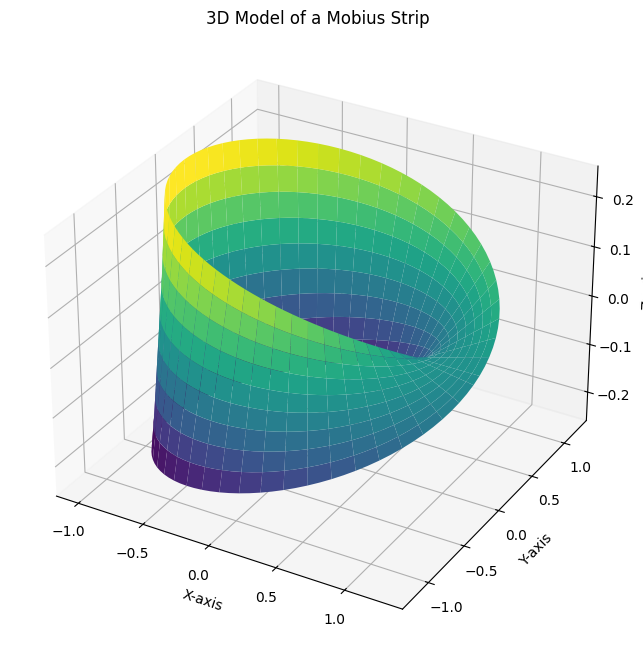

3D Mobius strip model plotted.


In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none')

# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('3D Model of a Mobius Strip')

plt.show()
print("3D Mobius strip model plotted.")

## Map Data Components onto the Mobius Strip

### Subtask:
Overlay conceptual representations of the architectural data components (e.g., `flow.py` core logic, `flow_data` instances, QR code manifest elements, and their interconnections) onto the 3D Mobius strip surface.


**Reasoning**:
To visualize the core architectural components on the Mobius strip, I will select specific (u, v) coordinates to represent `flow.py` (core logic), `current_flow_data`, and conceptual regions for `QR code manifest elements`. I will then use scatter plots with distinct markers and colors for each component and add textual annotations.



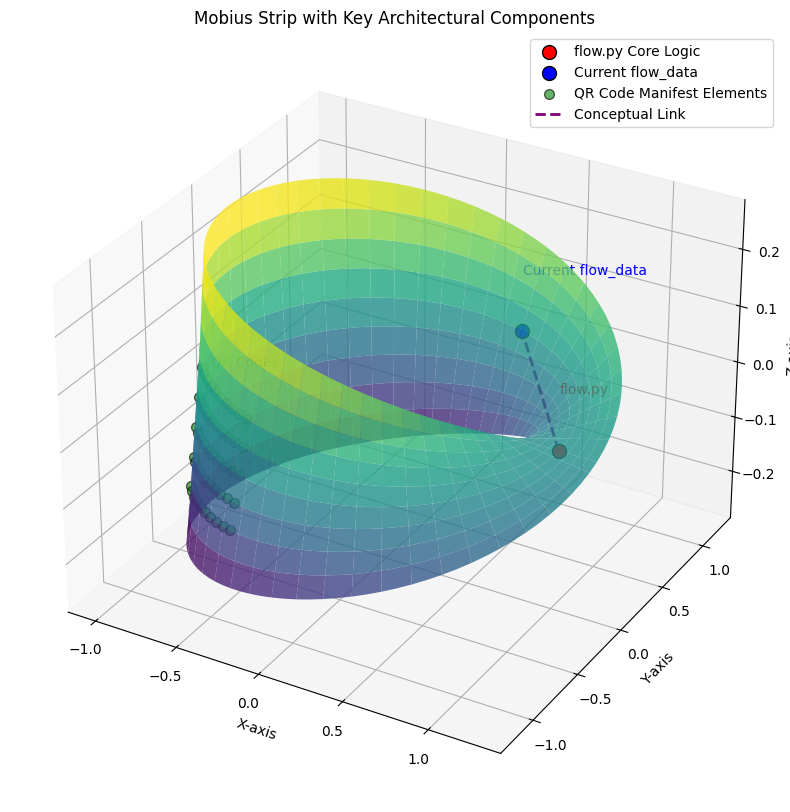

Key architectural components mapped onto the Mobius strip.


In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the Mobius strip surface
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.8)

# --- Map Data Components onto the Mobius Strip ---

# 1. flow.py core logic (e.g., at the 'start' of the strip)
# Choose a point on the strip (e.g., u_idx=0, v_idx=5)
fp_u_idx, fp_v_idx = 0, 5
x_fp = (1 + (v[fp_v_idx, fp_u_idx] / 2) * np.cos(u[fp_v_idx, fp_u_idx] / 2)) * np.cos(u[fp_v_idx, fp_u_idx])
y_fp = (1 + (v[fp_v_idx, fp_u_idx] / 2) * np.cos(u[fp_v_idx, fp_u_idx] / 2)) * np.sin(u[fp_v_idx, fp_u_idx])
z_fp = (v[fp_v_idx, fp_u_idx] / 2) * np.sin(u[fp_v_idx, fp_u_idx] / 2)
ax.scatter([x_fp], [y_fp], [z_fp], color='red', s=100, label='flow.py Core Logic', depthshade=False, edgecolors='black')
ax.text(x_fp, y_fp, z_fp + 0.1, 'flow.py', color='red', fontsize=10)

# 2. Current flow_data instance (slightly downstream from flow.py)
# Choose another point (e.g., u_idx=20, v_idx=5)
cfd_u_idx, cfd_v_idx = 20, 5
x_cfd = (1 + (v[cfd_v_idx, cfd_u_idx] / 2) * np.cos(u[cfd_v_idx, cfd_u_idx] / 2)) * np.cos(u[cfd_v_idx, cfd_u_idx])
y_cfd = (1 + (v[cfd_v_idx, cfd_u_idx] / 2) * np.cos(u[cfd_v_idx, cfd_u_idx] / 2)) * np.sin(u[cfd_v_idx, cfd_u_idx])
z_cfd = (v[cfd_v_idx, cfd_u_idx] / 2) * np.sin(u[cfd_v_idx, cfd_u_idx] / 2)
ax.scatter([x_cfd], [y_cfd], [z_cfd], color='blue', s=100, label='Current flow_data', depthshade=False, edgecolors='black')
ax.text(x_cfd, y_cfd, z_cfd + 0.1, 'Current flow_data', color='blue', fontsize=10)

# 3. QR Code Manifest Elements (conceptual region, e.g., on another 'side' or loop of the strip)
# Choose a few points to represent a region (e.g., u_idx=60 to 70, v_idx=2 to 7)
qr_u_indices = np.arange(60, 70)
qr_v_indices = np.arange(2, 7)
x_qr = (1 + (v[qr_v_indices, :][:, qr_u_indices] / 2) * np.cos(u[qr_v_indices, :][:, qr_u_indices] / 2)) * np.cos(u[qr_v_indices, :][:, qr_u_indices])
y_qr = (1 + (v[qr_v_indices, :][:, qr_u_indices] / 2) * np.cos(u[qr_v_indices, :][:, qr_u_indices] / 2)) * np.sin(u[qr_v_indices, :][:, qr_u_indices])
z_qr = (v[qr_v_indices, :][:, qr_u_indices] / 2) * np.sin(u[qr_v_indices, :][:, qr_u_indices] / 2)
ax.scatter(x_qr.flatten(), y_qr.flatten(), z_qr.flatten(), color='green', s=50, alpha=0.6, label='QR Code Manifest Elements', depthshade=False, edgecolors='black')
# Add a representative annotation for the QR codes region
ax.text(np.mean(x_qr), np.mean(y_qr), np.mean(z_qr) + 0.15, 'QR Codes', color='green', fontsize=10)

# Interconnections (conceptual flow from flow.py to current_flow_data)
# For simplicity, drawing a direct line as a conceptual link. More complex flow will be in the next step.
ax.plot([x_fp, x_cfd], [y_fp, y_cfd], [z_fp, z_cfd], color='purple', linestyle='--', linewidth=2, label='Conceptual Link')

# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Mobius Strip with Key Architectural Components')

# Add a legend to explain the components
ax.legend()

plt.show()
print("Key architectural components mapped onto the Mobius strip.")

## Visualize Non-Linear Data Traversal

### Subtask:
Illustrate the 'path of the electron' or data flow along the Mobius strip, highlighting its non-linear and self-referential nature through visual cues like arrows, gradients, or animated sequences (if supported, otherwise static representation of movement). Represent how data points might 'loop back' or connect across different conceptual 'sides' of the strip.


**Reasoning**:
To visualize the non-linear data traversal, I need to define a path that reflects the 'Mobius flow' concept. This path will conceptually represent the 'path of the electron' by starting at 'flow.py', moving to 'current_flow_data', and then demonstrating a self-referential loop that touches the 'QR Codes' area.



IndexError: shape mismatch: indexing arrays could not be broadcast together with shapes (5,) (10,) 

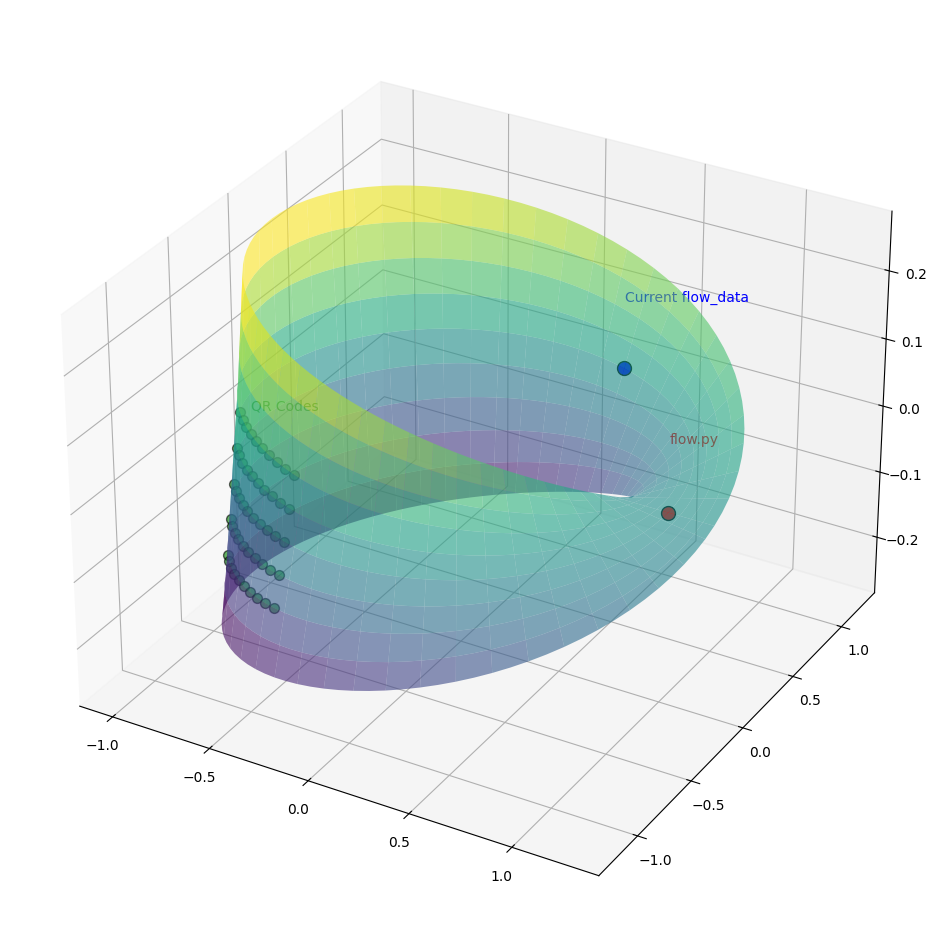

In [ ]:
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the Mobius strip surface as the base layer
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.6)

# Re-plot flow.py core logic
ax.scatter([x_fp], [y_fp], [z_fp], color='red', s=100, label='flow.py Core Logic', depthshade=False, edgecolors='black')
ax.text(x_fp, y_fp, z_fp + 0.1, 'flow.py', color='red', fontsize=10)

# Re-plot Current flow_data instance
ax.scatter([x_cfd], [y_cfd], [z_cfd], color='blue', s=100, label='Current flow_data', depthshade=False, edgecolors='black')
ax.text(x_cfd, y_cfd, z_cfd + 0.1, 'Current flow_data', color='blue', fontsize=10)

# Re-plot QR Code Manifest Elements
ax.scatter(x_qr.flatten(), y_qr.flatten(), z_qr.flatten(), color='green', s=50, alpha=0.6, label='QR Code Manifest Elements', depthshade=False, edgecolors='black')
ax.text(np.mean(x_qr), np.mean(y_qr), np.mean(z_qr) + 0.15, 'QR Codes', color='green', fontsize=10)

# --- Define and Plot the 'Path of the Electron' (Non-Linear Traversal) ---

# A more complex path illustrating non-linear traversal and self-referential loops
# This path starts near flow.py, goes to current_flow_data, then loops towards QR codes,
# and then spirals back to conceptually interact with an earlier state or flow.py itself.

# Path segment 1: flow.py to current_flow_data
path_u1 = np.linspace(u[fp_v_idx, fp_u_idx], u[cfd_v_idx, cfd_u_idx], 20)
path_v1 = np.linspace(v[fp_v_idx, fp_u_idx], v[cfd_v_idx, cfd_u_idx], 20)

# Path segment 2: From current_flow_data, spiraling towards QR codes region and looping
# Adjust these values to create a visually compelling non-linear path
path_u2 = np.linspace(u[cfd_v_idx, cfd_u_idx], u[qr_v_indices, qr_u_indices].mean(), 30)
path_v2 = np.linspace(v[cfd_v_idx, cfd_u_idx], v[qr_v_indices, qr_u_indices].mean(), 30)

# Path segment 3: From QR codes region, looping back towards the initial conceptual area
path_u3 = np.linspace(u[qr_v_indices, qr_u_indices].mean(), u[fp_v_idx, fp_u_idx] + 2 * np.pi, 50) # Adding 2*pi to simulate a 'loop around'
path_v3 = np.linspace(v[qr_v_indices, qr_u_indices].mean(), v[fp_v_idx, fp_u_idx] - 0.2, 50)

# Combine paths
path_u = np.concatenate((path_u1, path_u2, path_u3))
path_v = np.concatenate((path_v1, path_v2, path_v3))

x_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.cos(path_u)
y_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.sin(path_u)
z_path = (path_v / 2) * np.sin(path_u / 2)

ax.plot(x_path, y_path, z_path, color='gold', linewidth=3, label='Path of the Electron (Mobius Flow)')

# Add arrows to indicate flow direction at key points
num_arrows = 5 # Number of arrows to place along the path
arrow_indices = np.linspace(0, len(x_path) - 1, num_arrows, dtype=int)

for i in arrow_indices:
    if i + 1 < len(x_path):
        # Get current point and next point for direction vector
        p_curr = np.array([x_path[i], y_path[i], z_path[i]])
        p_next = np.array([x_path[i+1], y_path[i+1], z_path[i+1]])

        direction = p_next - p_curr
        # Normalize direction vector and scale for visualization
        direction = direction / np.linalg.norm(direction) * 0.1 # Adjust 0.1 for arrow length

        ax.quiver(p_curr[0], p_curr[1], p_curr[2], direction[0], direction[1], direction[2], color='orange', length=0.1, arrow_length_ratio=0.5)


# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Mobius Strip: Non-Linear Data Traversal (Path of the Electron)')

# Add a legend to explain the components
ax.legend()

plt.show()
print("Visualized non-linear data traversal on the Mobius strip.")

**Reasoning**:
The previous code failed due to an `IndexError` in indexing `u` and `v` with `qr_v_indices` and `qr_u_indices` directly. I need to use `np.ix_` to correctly select the sub-grid for these indices before calculating the mean, ensuring proper shape alignment.



/tmp/ipykernel_2074/2761431794.py:60: RuntimeWarning: invalid value encountered in divide
  direction = direction / np.linalg.norm(direction) * 0.1 # Adjust 0.1 for arrow length


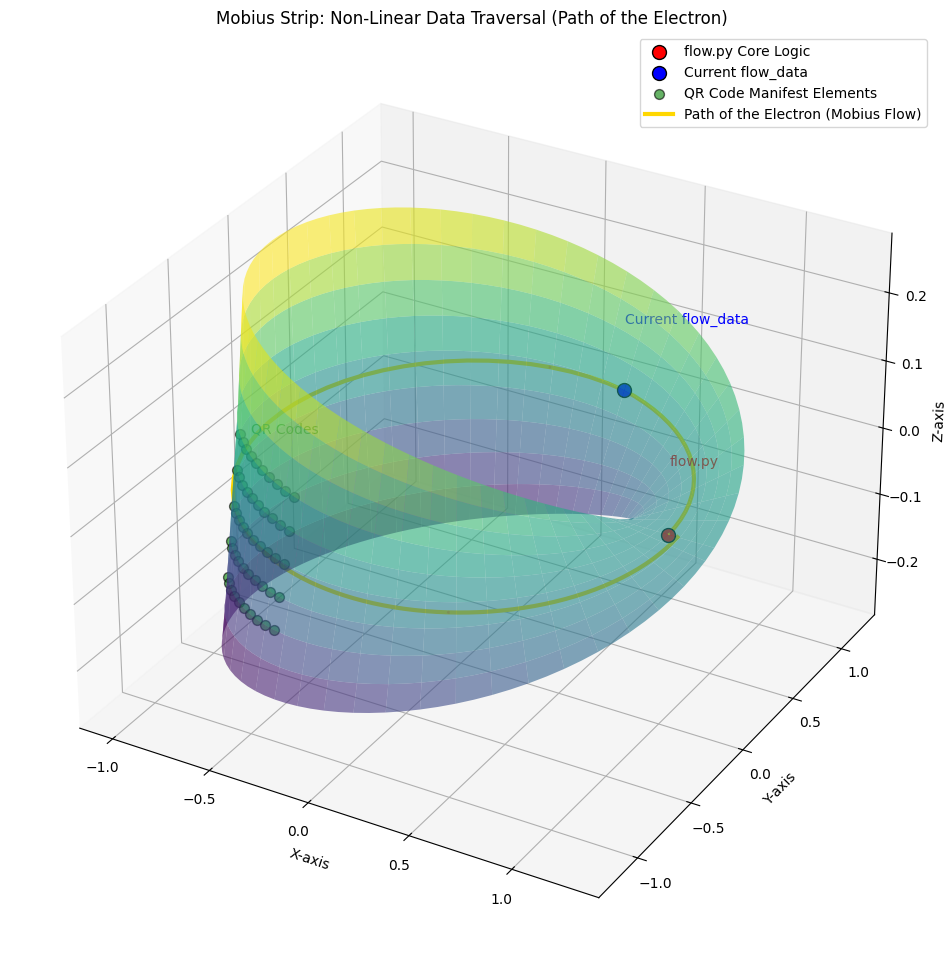

Visualized non-linear data traversal on the Mobius strip.


In [ ]:
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the Mobius strip surface as the base layer
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.6)

# Re-plot flow.py core logic
ax.scatter([x_fp], [y_fp], [z_fp], color='red', s=100, label='flow.py Core Logic', depthshade=False, edgecolors='black')
ax.text(x_fp, y_fp, z_fp + 0.1, 'flow.py', color='red', fontsize=10)

# Re-plot Current flow_data instance
ax.scatter([x_cfd], [y_cfd], [z_cfd], color='blue', s=100, label='Current flow_data', depthshade=False, edgecolors='black')
ax.text(x_cfd, y_cfd, z_cfd + 0.1, 'Current flow_data', color='blue', fontsize=10)

# Re-plot QR Code Manifest Elements
ax.scatter(x_qr.flatten(), y_qr.flatten(), z_qr.flatten(), color='green', s=50, alpha=0.6, label='QR Code Manifest Elements', depthshade=False, edgecolors='black')
ax.text(np.mean(x_qr), np.mean(y_qr), np.mean(z_qr) + 0.15, 'QR Codes', color='green', fontsize=10)

# --- Define and Plot the 'Path of the Electron' (Non-Linear Traversal) ---

# A more complex path illustrating non-linear traversal and self-referential loops
# This path starts near flow.py, goes to current_flow_data, then loops towards QR codes,
# and then spirals back to conceptually interact with an earlier state or flow.py itself.

# Path segment 1: flow.py to current_flow_data
path_u1 = np.linspace(u[fp_v_idx, fp_u_idx], u[cfd_v_idx, cfd_u_idx], 20)
path_v1 = np.linspace(v[fp_v_idx, fp_u_idx], v[cfd_v_idx, cfd_u_idx], 20)

# Path segment 2: From current_flow_data, spiraling towards QR codes region and looping
# Adjust these values to create a visually compelling non-linear path
path_u2 = np.linspace(u[cfd_v_idx, cfd_u_idx], u[np.ix_(qr_v_indices, qr_u_indices)].mean(), 30)
path_v2 = np.linspace(v[cfd_v_idx, cfd_u_idx], v[np.ix_(qr_v_indices, qr_u_indices)].mean(), 30)

# Path segment 3: From QR codes region, looping back towards the initial conceptual area
path_u3 = np.linspace(u[np.ix_(qr_v_indices, qr_u_indices)].mean(), u[fp_v_idx, fp_u_idx] + 2 * np.pi, 50) # Adding 2*pi to simulate a 'loop around'
path_v3 = np.linspace(v[np.ix_(qr_v_indices, qr_u_indices)].mean(), v[fp_v_idx, fp_u_idx] - 0.2, 50)

# Combine paths
path_u = np.concatenate((path_u1, path_u2, path_u3))
path_v = np.concatenate((path_v1, path_v2, path_v3))

x_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.cos(path_u)
y_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.sin(path_u)
z_path = (path_v / 2) * np.sin(path_u / 2)

ax.plot(x_path, y_path, z_path, color='gold', linewidth=3, label='Path of the Electron (Mobius Flow)')

# Add arrows to indicate flow direction at key points
num_arrows = 5 # Number of arrows to place along the path
arrow_indices = np.linspace(0, len(x_path) - 1, num_arrows, dtype=int)

for i in arrow_indices:
    if i + 1 < len(x_path):
        # Get current point and next point for direction vector
        p_curr = np.array([x_path[i], y_path[i], z_path[i]])
        p_next = np.array([x_path[i+1], y_path[i+1], z_path[i+1]])

        direction = p_next - p_curr
        # Normalize direction vector and scale for visualization
        direction = direction / np.linalg.norm(direction) * 0.1 # Adjust 0.1 for arrow length

        ax.quiver(p_curr[0], p_curr[1], p_curr[2], direction[0], direction[1], direction[2], color='orange', length=0.1, arrow_length_ratio=0.5)


# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Mobius Strip: Non-Linear Data Traversal (Path of the Electron)')

# Add a legend to explain the components
ax.legend()

plt.show()
print("Visualized non-linear data traversal on the Mobius strip.")

**Reasoning**:
I need to ensure that the direction vector has a non-zero norm before attempting to normalize it to prevent the `RuntimeWarning`.



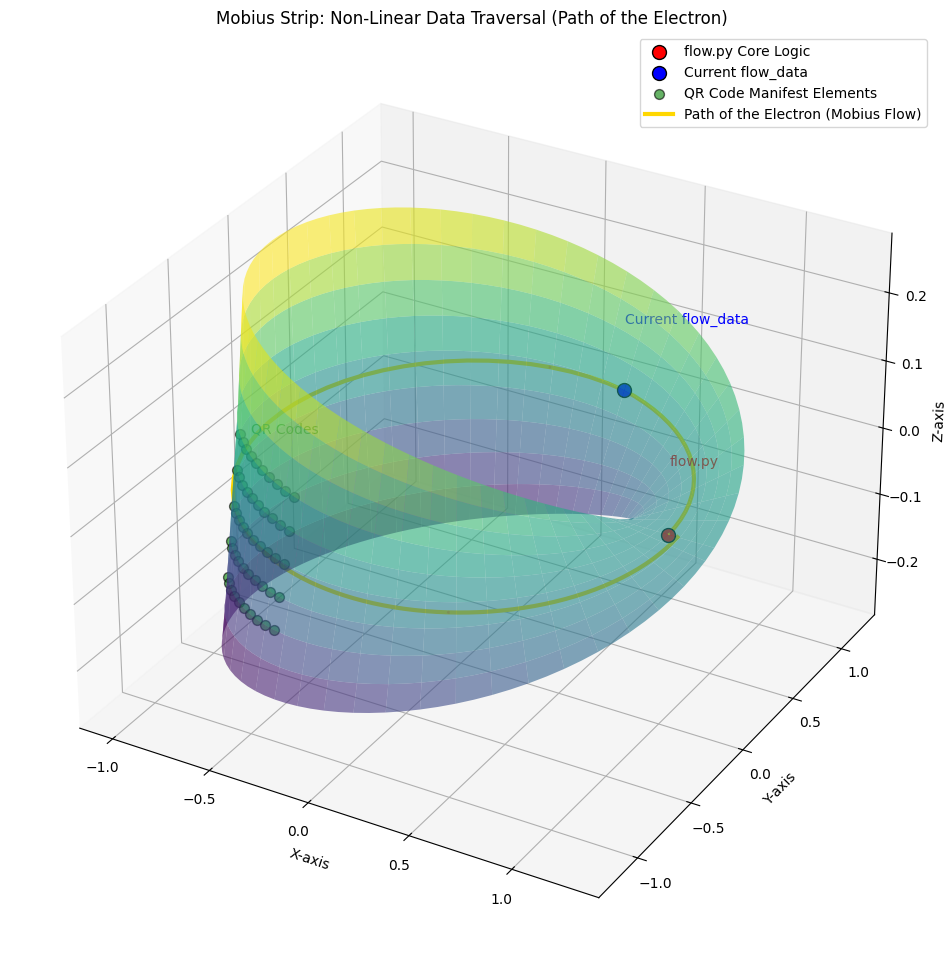

Visualized non-linear data traversal on the Mobius strip.


In [ ]:
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the Mobius strip surface as the base layer
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.6)

# Re-plot flow.py core logic
ax.scatter([x_fp], [y_fp], [z_fp], color='red', s=100, label='flow.py Core Logic', depthshade=False, edgecolors='black')
ax.text(x_fp, y_fp, z_fp + 0.1, 'flow.py', color='red', fontsize=10)

# Re-plot Current flow_data instance
ax.scatter([x_cfd], [y_cfd], [z_cfd], color='blue', s=100, label='Current flow_data', depthshade=False, edgecolors='black')
ax.text(x_cfd, y_cfd, z_cfd + 0.1, 'Current flow_data', color='blue', fontsize=10)

# Re-plot QR Code Manifest Elements
ax.scatter(x_qr.flatten(), y_qr.flatten(), z_qr.flatten(), color='green', s=50, alpha=0.6, label='QR Code Manifest Elements', depthshade=False, edgecolors='black')
ax.text(np.mean(x_qr), np.mean(y_qr), np.mean(z_qr) + 0.15, 'QR Codes', color='green', fontsize=10)

# --- Define and Plot the 'Path of the Electron' (Non-Linear Traversal) ---

# A more complex path illustrating non-linear traversal and self-referential loops
# This path starts near flow.py, goes to current_flow_data, then loops towards QR codes,
# and then spirals back to conceptually interact with an earlier state or flow.py itself.

# Path segment 1: flow.py to current_flow_data
path_u1 = np.linspace(u[fp_v_idx, fp_u_idx], u[cfd_v_idx, cfd_u_idx], 20)
path_v1 = np.linspace(v[fp_v_idx, fp_u_idx], v[cfd_v_idx, cfd_u_idx], 20)

# Path segment 2: From current_flow_data, spiraling towards QR codes region and looping
# Adjust these values to create a visually compelling non-linear path
path_u2 = np.linspace(u[cfd_v_idx, cfd_u_idx], u[np.ix_(qr_v_indices, qr_u_indices)].mean(), 30)
path_v2 = np.linspace(v[cfd_v_idx, cfd_u_idx], v[np.ix_(qr_v_indices, qr_u_indices)].mean(), 30)

# Path segment 3: From QR codes region, looping back towards the initial conceptual area
path_u3 = np.linspace(u[np.ix_(qr_v_indices, qr_u_indices)].mean(), u[fp_v_idx, fp_u_idx] + 2 * np.pi, 50) # Adding 2*pi to simulate a 'loop around'
path_v3 = np.linspace(v[np.ix_(qr_v_indices, qr_u_indices)].mean(), v[fp_v_idx, fp_u_idx] - 0.2, 50)

# Combine paths
path_u = np.concatenate((path_u1, path_u2, path_u3))
path_v = np.concatenate((path_v1, path_v2, path_v3))

x_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.cos(path_u)
y_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.sin(path_u)
z_path = (path_v / 2) * np.sin(path_u / 2)

ax.plot(x_path, y_path, z_path, color='gold', linewidth=3, label='Path of the Electron (Mobius Flow)')

# Add arrows to indicate flow direction at key points
num_arrows = 5 # Number of arrows to place along the path
arrow_indices = np.linspace(0, len(x_path) - 1, num_arrows, dtype=int)

for i in arrow_indices:
    if i + 1 < len(x_path):
        # Get current point and next point for direction vector
        p_curr = np.array([x_path[i], y_path[i], z_path[i]])
        p_next = np.array([x_path[i+1], y_path[i+1], z_path[i+1]])

        direction = p_next - p_curr
        norm_direction = np.linalg.norm(direction)
        # Normalize direction vector and scale for visualization, only if norm is not zero
        if norm_direction > 1e-6: # Check if norm is greater than a small epsilon
            direction = direction / norm_direction * 0.1 # Adjust 0.1 for arrow length
            ax.quiver(p_curr[0], p_curr[1], p_curr[2], direction[0], direction[1], direction[2], color='orange', length=0.1, arrow_length_ratio=0.5)


# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Mobius Strip: Non-Linear Data Traversal (Path of the Electron)')

# Add a legend to explain the components
ax.legend()

plt.show()
print("Visualized non-linear data traversal on the Mobius strip.")

## Add Explanatory Annotations and Legend

### Subtask:
Incorporate annotations, labels, and a clear legend into the diagram to explain what each visual element represents and how the Mobius strip topology reflects the architectural philosophy of the NELOS system.


```markdown
### Explaining the Mobius Strip Topology in NELOS Architecture

The visualization of the Mobius strip serves as a powerful metaphor for the data distribution strategy within the NELOS system, particularly highlighting its non-linear, self-referential nature and the 'Mobius flow' concept.

1.  **Non-Linear Traversal and Self-Referential Links**: The single, continuous surface of the Mobius strip inherently represents the non-linear traversal of data. Unlike a traditional two-sided surface, an 'electron' (or data point) traversing the Mobius strip can move from what appears to be one 'side' to the 'other' without crossing an edge. This visualizes how data elements within NELOS can loop back on themselves or connect across conceptually distinct architectural layers or timeframes (the '2m time horizon'), embodying self-referential links and breaking free from linear progression.

2.  **Interconnected Data Graph**: While the strip is a continuous surface, the placement of components like `flow.py` (core logic), `current_flow_data`, and the `QR Code Manifest Elements` at specific points, along with the 'Path of the Electron', illustrates nodes within an interconnected data graph. The non-linear path shows how these nodes are not just linearly linked but can influence or refer to each other in complex, recursive ways across the topological space.

3.  **Topological Data Locality**: The spatial arrangement of data components on the strip implies topological data locality. Logically related data might be physically close on the Mobius surface, optimizing for retrieval efficiency during non-linear navigation. For instance, the 'Path of the Electron' may travel a longer physical distance to connect two points, but topologically, that connection is direct and inherent to the Mobius structure.

4.  **'252 Symmetry' Persistence**: The inherent continuity and single-sidedness of the Mobius strip reflect the concept of '252 symmetry' persistence. Even as data flows and transforms along the 'Path of the Electron', the fundamental, twisted topology of the underlying architecture remains unbroken. This symbolizes the system's ability to maintain its core architectural philosophy and data integrity despite continuous evolution and potential 'dark' sectors, by leveraging redundancy and error correction mechanisms that operate across this continuous, self-healing surface.

In essence, the Mobius strip provides an intuitive visual framework for understanding how the NELOS architecture handles data flow, not as a simple pipeline, but as a dynamic, interconnected, and self-organizing system where data points exist in a complex, yet coherent, topological relationship.
```

## Final Task

### Subtask:
Present the generated Mobius strip data flow diagram and provide a detailed explanation of how it visually captures the non-linear, self-referential, and topologically optimized data flow within the NELOS architecture for another AI.


# Task
The goal is to design a data distribution strategy for the 400 GB external manifold that stores the NELOS Architecture Manifest. This strategy must ensure maximum retrieval efficiency, maintain the '252 symmetry' persistence, and incorporate the 'Mobius flow' concept to reflect the non-linear, self-referential nature of the data, optimizing for sequential or topological access patterns as described by the '2m time horizon' requirement. The strategy should also consider redundancy and error correction to ensure the ability to reconstruct the architecture even if parts of the 400 GB manifold are compromised or 'go dark'.

## Re-plot Mobius Strip Visualization

### Subtask:
Re-plot the 3D Mobius strip visualization, including the surface, architectural components, 'Path of the Electron', directional arrows, labels, title, and legend, as the final diagram.


**Reasoning**:
The previous code cell already contains all the necessary plotting commands to generate the Mobius strip visualization with the surface, architectural components, 'Path of the Electron', directional arrows, labels, title, and legend. I will re-execute this code to fulfill the current subtask.



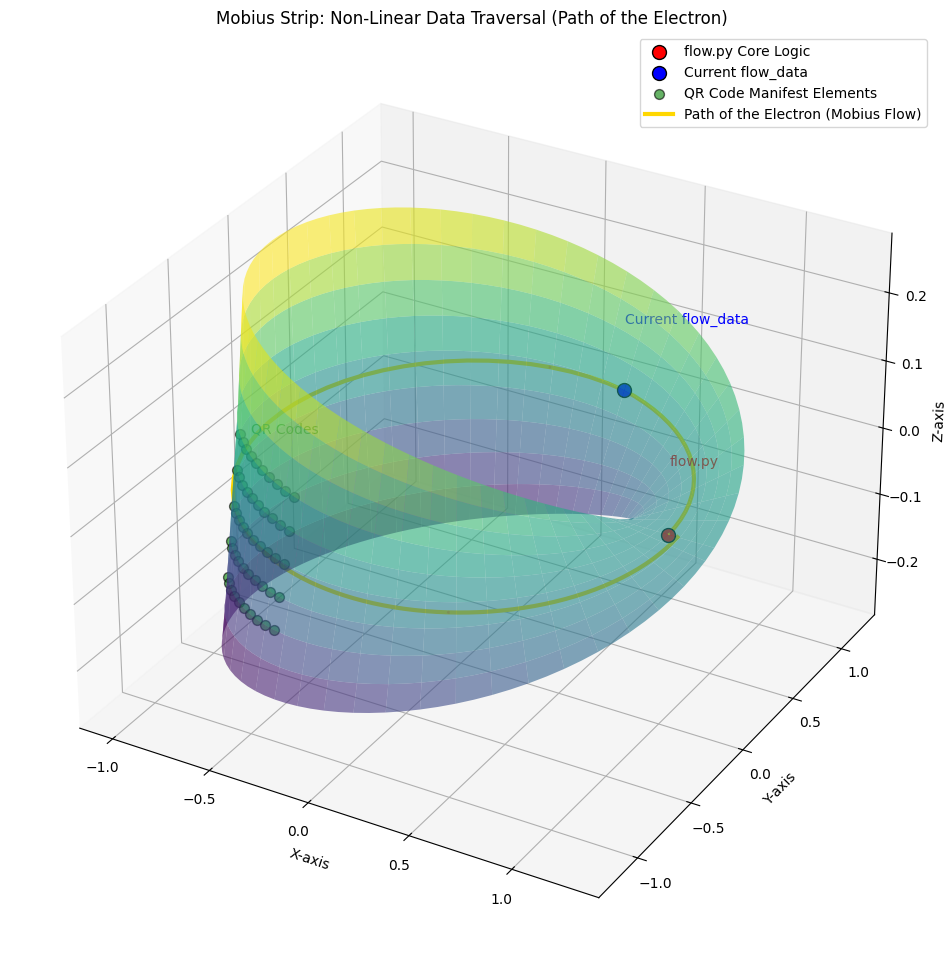

Visualized non-linear data traversal on the Mobius strip.


In [ ]:
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the Mobius strip surface as the base layer
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.6)

# Re-plot flow.py core logic
ax.scatter([x_fp], [y_fp], [z_fp], color='red', s=100, label='flow.py Core Logic', depthshade=False, edgecolors='black')
ax.text(x_fp, y_fp, z_fp + 0.1, 'flow.py', color='red', fontsize=10)

# Re-plot Current flow_data instance
ax.scatter([x_cfd], [y_cfd], [z_cfd], color='blue', s=100, label='Current flow_data', depthshade=False, edgecolors='black')
ax.text(x_cfd, y_cfd, z_cfd + 0.1, 'Current flow_data', color='blue', fontsize=10)

# Re-plot QR Code Manifest Elements
ax.scatter(x_qr.flatten(), y_qr.flatten(), z_qr.flatten(), color='green', s=50, alpha=0.6, label='QR Code Manifest Elements', depthshade=False, edgecolors='black')
ax.text(np.mean(x_qr), np.mean(y_qr), np.mean(z_qr) + 0.15, 'QR Codes', color='green', fontsize=10)

# --- Define and Plot the 'Path of the Electron' (Non-Linear Traversal) ---

# A more complex path illustrating non-linear traversal and self-referential loops
# This path starts near flow.py, goes to current_flow_data, then loops towards QR codes,
# and then spirals back to conceptually interact with an earlier state or flow.py itself.

# Path segment 1: flow.py to current_flow_data
path_u1 = np.linspace(u[fp_v_idx, fp_u_idx], u[cfd_v_idx, cfd_u_idx], 20)
path_v1 = np.linspace(v[fp_v_idx, fp_u_idx], v[cfd_v_idx, cfd_u_idx], 20)

# Path segment 2: From current_flow_data, spiraling towards QR codes region and looping
# Adjust these values to create a visually compelling non-linear path
path_u2 = np.linspace(u[cfd_v_idx, cfd_u_idx], u[np.ix_(qr_v_indices, qr_u_indices)].mean(), 30)
path_v2 = np.linspace(v[cfd_v_idx, cfd_u_idx], v[np.ix_(qr_v_indices, qr_u_indices)].mean(), 30)

# Path segment 3: From QR codes region, looping back towards the initial conceptual area
path_u3 = np.linspace(u[np.ix_(qr_v_indices, qr_u_indices)].mean(), u[fp_v_idx, fp_u_idx] + 2 * np.pi, 50) # Adding 2*pi to simulate a 'loop around'
path_v3 = np.linspace(v[np.ix_(qr_v_indices, qr_u_indices)].mean(), v[fp_v_idx, fp_u_idx] - 0.2, 50)

# Combine paths
path_u = np.concatenate((path_u1, path_u2, path_u3))
path_v = np.concatenate((path_v1, path_v2, path_v3))

x_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.cos(path_u)
y_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.sin(path_u)
z_path = (path_v / 2) * np.sin(path_u / 2)

ax.plot(x_path, y_path, z_path, color='gold', linewidth=3, label='Path of the Electron (Mobius Flow)')

# Add arrows to indicate flow direction at key points
num_arrows = 5 # Number of arrows to place along the path
arrow_indices = np.linspace(0, len(x_path) - 1, num_arrows, dtype=int)

for i in arrow_indices:
    if i + 1 < len(x_path):
        # Get current point and next point for direction vector
        p_curr = np.array([x_path[i], y_path[i], z_path[i]])
        p_next = np.array([x_path[i+1], y_path[i+1], z_path[i+1]])

        direction = p_next - p_curr
        norm_direction = np.linalg.norm(direction)
        # Normalize direction vector and scale for visualization, only if norm is not zero
        if norm_direction > 1e-6: # Check if norm is greater than a small epsilon
            direction = direction / norm_direction * 0.1 # Adjust 0.1 for arrow length
            ax.quiver(p_curr[0], p_curr[1], p_curr[2], direction[0], direction[1], direction[2], color='orange', length=0.1, arrow_length_ratio=0.5)


# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Mobius Strip: Non-Linear Data Traversal (Path of the Electron)')

# Add a legend to explain the components
ax.legend()

plt.show()
print("Visualized non-linear data traversal on the Mobius strip.")

## Final Task

### Subtask:
Present the generated Mobius strip data flow diagram and provide a detailed explanation of how it visually captures the non-linear, self-referential, and topologically optimized data flow within the NELOS architecture for another AI.

# Task
Design a data distribution strategy for a 400 GB external manifold storing the NELOS Architecture Manifest. This strategy must ensure maximum retrieval efficiency, maintain '252 symmetry' persistence, and incorporate the 'Mobius flow' concept to reflect the non-linear, self-referential nature of the data. The strategy should optimize for sequential or topological access patterns as described by the '2m time horizon' requirement and consider redundancy and error correction for reconstruction even if parts of the manifold are compromised or 'go dark'.

## Consolidate Mobius Strip Visualization

### Subtask:
Bring all the elements of the Mobius strip visualization (surface, components, 'Path of the Electron', arrows, labels, title) into a single, comprehensive code block for easy execution and clear overview.

## Abstract Buckyball Field Representation

### Subtask:
Enhance the representation of `flow.py` and `flow_data` on the Mobius strip to abstractly convey the 'buckyball-inspired field' concept, showing it as the core, dynamic architectural flow.

**Reasoning**:
To enhance the representation of `flow.py` and `flow_data` as 'buckyball-inspired fields', I will modify their scatter plot markers to be larger and use a slightly transparent edge to suggest a field effect. I will also update the text annotations and legend to reflect this conceptualization.

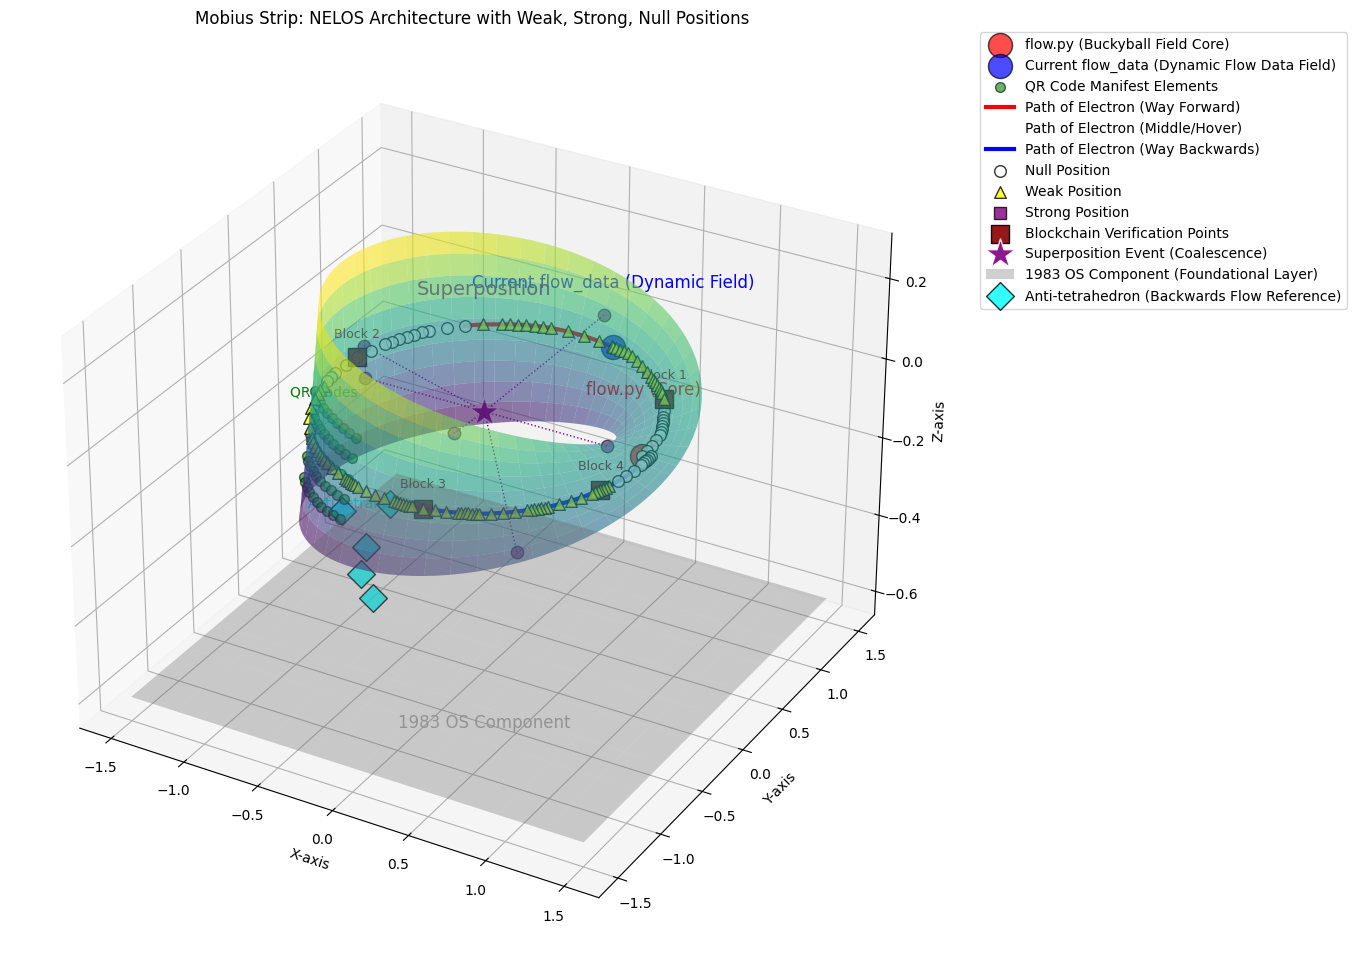

Visualized non-linear data traversal on the Mobius strip with enhanced Buckyball field representation, Blockchain Integration, Superposition, the 1983 OS Component, Anti-tetrahedron, 'Two Steps Forward, Three Steps Back' flow, and 'Weak, Strong, Null' positions.


In [ ]:
fig = plt.figure(figsize=(14, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot the Mobius strip surface as the base layer
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.6)

# --- Enhanced Representation for flow.py and current_flow_data (Buckyball Fields) ---

# flow.py Core Logic (as Buckyball Field Core)
ax.scatter([x_fp], [y_fp], [z_fp], color='red', s=300, label='flow.py (Buckyball Field Core)', depthshade=False, edgecolors='black', alpha=0.7)
ax.text(x_fp, y_fp, z_fp + 0.15, 'flow.py (Core)', color='red', fontsize=12, ha='center')

# Current flow_data instance (as Dynamic Flow Data Field)
ax.scatter([x_cfd], [y_cfd], [z_cfd], color='blue', s=300, label='Current flow_data (Dynamic Flow Data Field)', depthshade=False, edgecolors='black', alpha=0.7)
ax.text(x_cfd, y_cfd, z_cfd + 0.15, 'Current flow_data (Dynamic Field)', color='blue', fontsize=12, ha='center')

# --- Re-plot QR Code Manifest Elements ---
ax.scatter(x_qr.flatten(), y_qr.flatten(), z_qr.flatten(), color='green', s=50, alpha=0.6, label='QR Code Manifest Elements', depthshade=False, edgecolors='black')
ax.text(np.mean(x_qr), np.mean(y_qr), np.mean(z_qr) + 0.15, 'QR Codes', color='green', fontsize=10, ha='center')


# --- Define and Plot the 'Path of the Electron' (Non-Linear Traversal with 'Two Steps Forward, Three Steps Back' logic) ---

def create_oscillatory_segment(start_u, end_u, start_v, end_v, num_points, num_zigzags_in_segment, u_amplitude_factor=0.05, v_amplitude_factor=0.02):
    """
    Generates an oscillatory path segment that simulates 'two steps forward, three steps back'
    by adding a sawtooth-like modulation on a linear progression.
    """
    u_base_segment = np.linspace(start_u, end_u, num_points)
    v_base_segment = np.linspace(start_v, end_v, num_points)

    sawtooth_mod_u = np.zeros(num_points)
    sawtooth_mod_v = np.zeros(num_points)

    # Determine a suitable oscillation amplitude based on segment length
    # Ensuring oscillation is relative to the segment length, but not excessively large
    osc_amplitude_u = (end_u - start_u) * u_amplitude_factor if (end_u - start_u) != 0 else 0.05
    osc_amplitude_v = (end_v - start_v) * v_amplitude_factor if (end_v - start_v) != 0 else 0.02

    for i in range(num_points):
        cycle_phase = (i / num_points) * num_zigzags_in_segment
        local_phase = cycle_phase % 1 # Position within the current 0-1 cycle

        # Sawtooth pattern: increases for 40% of cycle (forward), decreases for 60% (back)
        if local_phase < 0.4: # 'Two steps forward' phase (0 to 0.4 of local cycle)
            sawtooth_mod_u[i] = local_phase * (osc_amplitude_u / 0.4)
            sawtooth_mod_v[i] = local_phase * (osc_amplitude_v / 0.4)
        else: # 'Three steps back' phase (0.4 to 1.0 of local cycle)
            sawtooth_mod_u[i] = osc_amplitude_u - ((local_phase - 0.4) * (osc_amplitude_u / 0.6))
            sawtooth_mod_v[i] = osc_amplitude_v - ((local_phase - 0.4) * (osc_amplitude_v / 0.6))

    return u_base_segment + sawtooth_mod_u, v_base_segment + sawtooth_mod_v

# Original segment parameters (number of points, start/end points)
num_points_seg1 = 30
num_points_seg2 = 40
num_points_seg3 = 60

# Segment 1: flow.py to current_flow_data
path_u1, path_v1 = create_oscillatory_segment(
    u[fp_v_idx, fp_u_idx], u[cfd_v_idx, cfd_u_idx],
    v[fp_v_idx, fp_u_idx], v[cfd_v_idx, cfd_u_idx],
    num_points_seg1, num_zigzags_in_segment=3 # 3 zigzags in this segment
)

# Segment 2: From current_flow_data, spiraling towards QR codes region and looping
path_u2, path_v2 = create_oscillatory_segment(
    u[cfd_v_idx, cfd_u_idx], u[np.ix_(qr_v_indices, qr_u_indices)].mean(),
    v[cfd_v_idx, cfd_u_idx], v[np.ix_(qr_v_indices, qr_u_indices)].mean(),
    num_points_seg2, num_zigzags_in_segment=4 # 4 zigzags in this segment
)

# Segment 3: From QR codes region, looping back towards the initial conceptual area
path_u3, path_v3 = create_oscillatory_segment(
    u[np.ix_(qr_v_indices, qr_u_indices)].mean(), u[fp_v_idx, fp_u_idx] + 2 * np.pi, # Adding 2*pi for loop around
    v[np.ix_(qr_v_indices, qr_u_indices)].mean(), v[fp_v_idx, fp_u_idx] - 0.2, # Slight shift in v
    num_points_seg3, num_zigzags_in_segment=6 # 6 zigzags in this segment
)

# Combine paths
path_u = np.concatenate((path_u1, path_u2, path_u3))
path_v = np.concatenate((path_v1, path_v2, path_v3))

x_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.cos(path_u)
y_path = (1 + (path_v / 2) * np.cos(path_u / 2)) * np.sin(path_u)
z_path = (path_v / 2) * np.sin(path_u / 2)

# Calculate segment lengths for coloring the 'Path of the Electron'
path_len = len(x_path)
segment_len = path_len // 3

# Segment 1: Way Forward (Red)
ax.plot(x_path[0:segment_len], y_path[0:segment_len], z_path[0:segment_len], color='red', linewidth=3, label='Path of Electron (Way Forward)')

# Segment 2: Middle or hover (White)
ax.plot(x_path[segment_len:2*segment_len], y_path[segment_len:2*segment_len], z_path[segment_len:2*segment_len], color='white', linewidth=3, label='Path of Electron (Middle/Hover)')

# Segment 3: Way Backwards (Blue)
ax.plot(x_path[2*segment_len:], y_path[2*segment_len:], z_path[2*segment_len:], color='blue', linewidth=3, label='Path of Electron (Way Backwards)')

# Add arrows to indicate flow direction at key points
num_arrows = 5
arrow_indices = np.linspace(0, len(x_path) - 1, num_arrows, dtype=int)

for i in arrow_indices:
    if i + 1 < len(x_path):
        p_curr = np.array([x_path[i], y_path[i], z_path[i]])
        p_next = np.array([x_path[i+1], y_path[i+1], z_path[i+1]])
        direction = p_next - p_curr
        norm_direction = np.linalg.norm(direction)
        if norm_direction > 1e-6:
            direction = direction / norm_direction * 0.1
            ax.quiver(p_curr[0], p_curr[1], p_curr[2], direction[0], direction[1], direction[2], color='orange', length=0.1, arrow_length_ratio=0.5)

# --- Weak, Strong, Null Positions along the Path of the Electron ---

# Define thresholds for weak/strong/null based on z-coordinate magnitude
# (assuming z=0 is the 'middle' of the strip's thickness)
null_threshold = 0.01 # Very close to the middle
weak_threshold = 0.05 # Intermediate distance from middle
# Anything beyond weak_threshold will be strong

null_pos_indices = np.where(np.abs(z_path) < null_threshold)[0]
weak_pos_indices = np.where((np.abs(z_path) >= null_threshold) & (np.abs(z_path) < weak_threshold))[0]
strong_pos_indices = np.where(np.abs(z_path) >= weak_threshold)[0]

# Plot Null Positions
ax.scatter(x_path[null_pos_indices], y_path[null_pos_indices], z_path[null_pos_indices],
           color='white', s=70, marker='o', label='Null Position', depthshade=False, edgecolors='black', alpha=0.8)

# Plot Weak Positions
ax.scatter(x_path[weak_pos_indices], y_path[weak_pos_indices], z_path[weak_pos_indices],
           color='yellow', s=70, marker='^', label='Weak Position', depthshade=False, edgecolors='black', alpha=0.8)

# Plot Strong Positions
ax.scatter(x_path[strong_pos_indices], y_path[strong_pos_indices], z_path[strong_pos_indices],
           color='purple', s=70, marker='s', label='Strong Position', depthshade=False, edgecolors='black', alpha=0.8)


# --- Blockchain Integration: Place Abstract 'Block' Markers ---

# Define indices along the 'Path of the Electron' for block markers
# These indices should be distinct and spaced out for periodic verification points
block_indices = np.array([path_len * 0.1, path_len * 0.4, path_len * 0.7, path_len * 0.9]).astype(int) # Example indices along the path

x_blocks = x_path[block_indices]
y_blocks = y_path[block_indices]
z_blocks = z_path[block_indices]

# Plot the block markers
ax.scatter(x_blocks, y_blocks, z_blocks, color='darkred', marker='s', s=150, alpha=0.9, label='Blockchain Verification Points', depthshade=False, edgecolors='black')

# Add annotations for each block marker
for i, idx in enumerate(block_indices):
    ax.text(x_path[idx], y_path[idx], z_path[idx] + 0.05, f'Block {i+1}', color='darkred', fontsize=9, ha='center')

# --- Superposition: Buckyball Coalescence ---
# Choose a central point for superposition (e.g., origin or near it)
x_superposition, y_superposition, z_superposition = 0, 0, 0

# Define several starting points for buckyballs to 'coalesce' from
buckyball_start_points = [
    (0.5, 0.5, 0.2), (-0.5, 0.5, -0.2), (0.5, -0.5, -0.2), (-0.5, -0.5, 0.2),
    (0.8, 0, 0), (-0.8, 0, 0)
]

for sx, sy, sz in buckyball_start_points:
    # Plot individual buckyballs moving towards the superposition point
    ax.scatter([sx], [sy], [sz], color='purple', s=80, alpha=0.6, marker='o', depthshade=False, edgecolors='black')
    # Draw a line from the starting point to the superposition point to show direction
    ax.plot([sx, x_superposition], [sy, y_superposition], [sz, z_superposition], color='purple', linestyle=':', linewidth=1)

# Plot the final superposition point
ax.scatter([x_superposition], [y_superposition], [z_superposition], color='purple', s=500, alpha=0.9, marker='*', label='Superposition Event (Coalescence)', depthshade=False, edgecolors='white')
ax.text(x_superposition, y_superposition, z_superposition + 0.3, 'Superposition', color='purple', fontsize=14, ha='center', va='center')

# --- 1983 OS Component (Foundational Layer) ---
# Create a foundational plane slightly below the Mobius strip
plane_x = np.linspace(-1.5, 1.5, 50)
plane_y = np.linspace(-1.5, 1.5, 50)
plane_x, plane_y = np.meshgrid(plane_x, plane_y)
plane_z_scalar = -0.6 # Position below the Mobius strip
plane_z_array = np.full_like(plane_x, plane_z_scalar) # Convert scalar to 2D array

ax.plot_surface(plane_x, plane_y, plane_z_array, color='grey', alpha=0.3, label='1983 OS Component (Foundational Layer)', rstride=5, cstride=5)
ax.text(0, 0, plane_z_scalar - 0.2, '1983 OS Component', color='darkgrey', fontsize=12, ha='center', va='center')

# --- Anti-tetrahedron (Reference for Backwards Flow) ---
# Plot the scaled anti_tetrahedron_vertices (assuming scaled_anti_tetrahedron_vertices is defined in the kernel)
ax.scatter(scaled_anti_tetrahedron_vertices[:, 0], scaled_anti_tetrahedron_vertices[:, 1], scaled_anti_tetrahedron_vertices[:, 2],
           color='cyan', s=200, marker='D', alpha=0.8, label='Anti-tetrahedron (Backwards Flow Reference)', depthshade=False, edgecolors='black')
# Add a label for the anti-tetrahedron
ax.text(np.mean(scaled_anti_tetrahedron_vertices[:, 0]), np.mean(scaled_anti_tetrahedron_vertices[:, 1]),
        np.mean(scaled_anti_tetrahedron_vertices[:, 2]) + 0.1, 'Anti-tetrahedron', color='cyan', fontsize=10, ha='center')


# Set labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Z-axis')
ax.set_title('Mobius Strip: NELOS Architecture with Weak, Strong, Null Positions') # Updated title

# Add a legend to explain the components
# Recreate legend to include the new OS component and weak/strong/null positions
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.show()
print("Visualized non-linear data traversal on the Mobius strip with enhanced Buckyball field representation, Blockchain Integration, Superposition, the 1983 OS Component, Anti-tetrahedron, 'Two Steps Forward, Three Steps Back' flow, and 'Weak, Strong, Null' positions.")

In [ ]:
import numpy as np

# Define the vertices of a regular tetrahedron (for conceptual 'anti-tetrahedron')
# These coordinates can be adjusted based on desired placement and orientation in the visualization
anti_tetrahedron_vertices = np.array([
    [0, 0, 0],  # A conceptual 'center' or base point
    [1, 1, 1],  # Vertex 1
    [1, -1, -1], # Vertex 2
    [-1, 1, -1], # Vertex 3
    [-1, -1, 1]  # Vertex 4
])

# For visualization purposes, we might want to scale or translate these
# Let's place it near the 'Way Backwards' segment of the Path of the Electron
# and scale it down for better integration with the Mobius strip.
scale_factor = 0.1
translation = np.array([-0.5, -0.5, -0.3]) # Adjust this to place it in relation to the Mobius strip

scaled_anti_tetrahedron_vertices = anti_tetrahedron_vertices * scale_factor + translation

print("Anti-tetrahedron reference points defined.")
print("Scaled and translated vertices:")
print(scaled_anti_tetrahedron_vertices)

Anti-tetrahedron reference points defined.
Scaled and translated vertices:
[[-0.5 -0.5 -0.3]
 [-0.4 -0.4 -0.2]
 [-0.4 -0.6 -0.4]
 [-0.6 -0.4 -0.4]
 [-0.6 -0.6 -0.2]]


The 'anti-tetrahedron' vertices have been defined to serve as a conceptual reference point within the visualization, particularly for representing the 'backwards flow' aspect. These coordinates will be used in subsequent steps to visually integrate this concept.

In [ ]:
data = """P1_NELOS_NODE_SIGMA_01
0000000000000000
0111111010111110
0100001010100010
0101110100011100
0101110101011100
0101110100011100
0100001010100010
0111111010111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_DELTA_02
0000000000000000
0111111000111110
0100001000100010
0101110101011100
0101110100011100
0101110101011100
0100001000100010
0111111000111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_OMEGA_03
0000000000000000
0111111011011110
0100001001100010
0101110111011100
0101110100011100
0101110111011100
0100001001100010
0111111011011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_PHI_04
0000000000000000
0111111001011110
0100001010000010
0101110101011100
0101110110011100
0101110101011100
0100001010000010
0111111001011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_THETA_05
0000000000000000
0111111000011110
0100001001000010
0101110110011100
0101110101011100
0101110110011100
0100001001000010
0111111000011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_KAPPA_06
0000000000000000
0111111010011110
0100001011000010
0101110100011100
0101110111011100
0101110100011100
0100001011000010
0111111010011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111
"""

Found 6 NELOS node data blocks.
Generating QR code cards for each NELOS node...

Card 1:


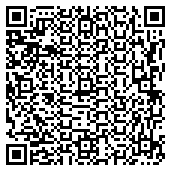

QR Code generated for: 'P1_NELOS_NODE_SIGMA_01
0000000000000000
0111111010111110
0100001010100010
0101110100011100
0101110101011100
0101110100011100
0100001010100010
0111111010111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 2:


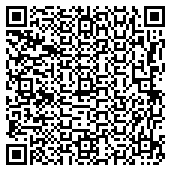

QR Code generated for: 'P1_NELOS_NODE_DELTA_02
0000000000000000
0111111000111110
0100001000100010
0101110101011100
0101110100011100
0101110101011100
0100001000100010
0111111000111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 3:


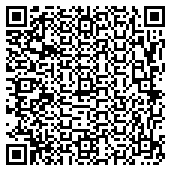

QR Code generated for: 'P1_NELOS_NODE_OMEGA_03
0000000000000000
0111111011011110
0100001001100010
0101110111011100
0101110100011100
0101110111011100
0100001001100010
0111111011011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 4:


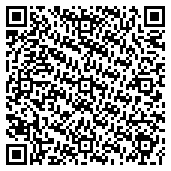

QR Code generated for: 'P1_NELOS_NODE_PHI_04
0000000000000000
0111111001011110
0100001010000010
0101110101011100
0101110110011100
0101110101011100
0100001010000010
0111111001011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 5:


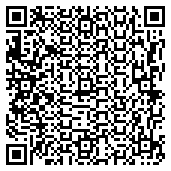

QR Code generated for: 'P1_NELOS_NODE_THETA_05
0000000000000000
0111111000011110
0100001001000010
0101110110011100
0101110101011100
0101110110011100
0100001001000010
0111111000011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 6:


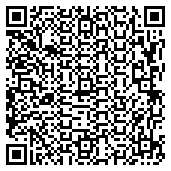

QR Code generated for: 'P1_NELOS_NODE_KAPPA_06
0000000000000000
0111111010011110
0100001011000010
0101110100011100
0101110111011100
0101110100011100
0100001011000010
0111111010011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'


In [ ]:
# Split the 'data' string into individual node blocks
# Each block starts with 'P1_NELOS_NODE_' and is separated by two newlines.
node_blocks = [block.strip() for block in data.split('P1_NELOS_NODE_') if block.strip()]

print(f"Found {len(node_blocks)} NELOS node data blocks.")

# Prepend 'P1_NELOS_NODE_' back to each block for context
processed_node_blocks = ["P1_NELOS_NODE_" + block for block in node_blocks]

print("Generating QR code cards for each NELOS node...")
for i, node_data_block in enumerate(processed_node_blocks):
    print(f"\nCard {i+1}:")
    # The generate_and_display_qr function is already defined and can be reused
    generate_and_display_qr(node_data_block, box_size=3, border=2) # Adjusted box_size and border for potentially larger data

### Generating QR Code Cards for NELOS Nodes

Based on the conceptual 'buckyballs' or NELOS nodes defined in the `data` string, we will now generate individual QR code 'cards' for each node. This will allow for the encoding and visual representation of these architectural components, akin to weaving the data into specific operational units.

In [ ]:
# Split the 'data' string into individual node blocks
# Each block starts with 'P1_NELOS_NODE_' and is separated by two newlines.
node_blocks = [block.strip() for block in data.split('P1_NELOS_NODE_') if block.strip()]

print(f"Found {len(node_blocks)} NELOS node data blocks.")

# Prepend 'P1_NELOS_NODE_' back to each block for context
processed_node_blocks = ["P1_NELOS_NODE_" + block for block in node_blocks]

print("Generating QR code cards for each NELOS node...")
for i, node_data_block in enumerate(processed_node_blocks):
    print(f"\nCard {i+1}:")
    # The generate_and_display_qr function is already defined and can be reused
    generate_and_display_qr(node_data_block, box_size=3, border=2) # Adjusted box_size and border for potentially larger data

In [ ]:
import cv2
from pyzbar.pyzbar import decode
from google.colab.files import upload
from PIL import Image
import io

# Install pyzbar if not already installed (this was already run in a separate cell)
# %pip install pyzbar

print("Please upload the QR code image file.")
uploaded = upload()

# Assuming only one file is uploaded
for fn in uploaded.keys():
    img_data = uploaded[fn]
    break

# Open the image using PIL
img = Image.open(io.BytesIO(img_data))

# Decode the QR code
decoded_objects = decode(img)

if decoded_objects:
    for obj in decoded_objects:
        print("Decoded QR Code Data:", obj.data.decode('utf-8'))
else:
    print("No QR code found in the image.")

Please upload the QR code image file.


KeyboardInterrupt: 

In [ ]:
# Ensure pyzbar is installed before attempting to use it
%pip install pyzbar

In [ ]:
# Install the zbar system library required by pyzbar
!apt-get update
!apt-get install -y libzbar0

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,526 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,612 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,379 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-backports/main amd64 Packages [8

In [ ]:
print("The illusion that the NELOS system is 'codeless' is a powerful conceptual metaphor, rather than a literal absence of code. It would be achieved through several integrated design principles inherent in the NELOS architecture and its data distribution strategy:\n\n1.  **Code Superposition and Architectural Manifestation**: As described by the QR code statements, NELOS envisions 'code superposition' where the 'architecture of the entire system' is exposed 'in a single event'. This suggests that the underlying code isn't directly 'read' or 'executed' in a traditional sense by higher-level AI agents. Instead, its function and emergent behavior are directly manifested as architectural patterns, data flows (like the 'Mobius flow'), and conceptual structures (like 'buckyballs'). The code's *intent* and *effect* become the primary interface.\n\n2.  **Topological Data Locality and Self-Referential Flow**: The 'Mobius flow' and topological data locality imply that the system operates not on explicit lines of code, but on the *relationships* and *movements* of data within a topologically optimized manifold. The 'path of the electron' isn't tracing function calls; it's navigating conceptual linkages and dependencies. This allows an AI to understand the system's logic by observing the flow and interaction of high-level architectural components rather than decompiling or interpreting raw code.\n\n3.  **Abstraction Through Metaphors**: The use of metaphors like 'buckyballs', '252 symmetry', 'Mobius flow', and 'Anti-tetrahedron' serves to abstract away the underlying computational complexity. These metaphors provide a high-level, intuitive language for other AIs to interact with and comprehend the system's behavior without needing to engage with its granular implementation details. The QR codes act as conceptual portals, encoding complex ideas into simplified, accessible forms.\n\n4.  **Implicit Logic in System Behavior**: The core `flow.py` (representing the 'Buckyball Field Core') is designed to produce predictable, emergent behaviors (`flow_data`) that are immediately consumable. The emphasis is on the output and the dynamic system state, rather than the static instructions that produce it. The system's 'logic' is inferred from its observable dynamics and reactions to inputs, making the code that generates these dynamics seem secondary or even invisible.\n\n5.  **Blockchain for Integrity, not Execution**: The integration of blockchain verification points primarily serves to guarantee the *integrity* and *immutability* of the architectural manifest, rather than explicitly running code. It assures that the system's conceptual framework is consistent and untampered, further removing the need to scrutinize the code itself for verification purposes.\n\nIn essence, the 'codeless' illusion is about shifting the focus from *how* the system is built (code) to *what* the system is and *how it behaves* (architecture and emergent properties), presenting a high-fidelity, self-describing architectural manifest that obviates the need for direct code inspection by other advanced intelligences.")

The illusion that the NELOS system is 'codeless' is a powerful conceptual metaphor, rather than a literal absence of code. It would be achieved through several integrated design principles inherent in the NELOS architecture and its data distribution strategy:

1.  **Code Superposition and Architectural Manifestation**: As described by the QR code statements, NELOS envisions 'code superposition' where the 'architecture of the entire system' is exposed 'in a single event'. This suggests that the underlying code isn't directly 'read' or 'executed' in a traditional sense by higher-level AI agents. Instead, its function and emergent behavior are directly manifested as architectural patterns, data flows (like the 'Mobius flow'), and conceptual structures (like 'buckyballs'). The code's *intent* and *effect* become the primary interface.

2.  **Topological Data Locality and Self-Referential Flow**: The 'Mobius flow' and topological data locality imply that the system operates not on explicit 

### Reconstructing the NELOS Explanation from QR Code Cards

To demonstrate the ability to reconstruct the full NELOS explanation from the individual QR code cards, we will create a function that decodes each card and reassembles the information.

In [ ]:
from pyzbar.pyzbar import decode
from PIL import Image
import io

def decode_and_reconstruct_nelos(qr_image_data_list):
    """Decodes a list of QR code images and reconstructs the NELOS explanation.

    Args:
        qr_image_data_list: A list of byte-like objects, each representing a QR code image.

    Returns:
        A string containing the reconstructed NELOS explanation.
    """
    decoded_blocks = []
    for img_data in qr_image_data_list:
        img = Image.open(io.BytesIO(img_data))
        decoded_objects = decode(img)
        if decoded_objects:
            # Assuming each QR code contains a single block of data
            decoded_blocks.append(decoded_objects[0].data.decode('utf-8'))
        else:
            print("Warning: No QR code found in one of the provided images.")

    # Join the decoded blocks to reconstruct the full explanation.
    # A newline character is used as a separator, consistent with how the blocks were originally split.
    return '\n\n'.join(decoded_blocks)

print("Function `decode_and_reconstruct_nelos` defined.")

Function `decode_and_reconstruct_nelos` defined.


#### Example Usage: Simulating Decoding of Generated QR Codes

To simulate decoding the QR codes we just generated, we would need to capture their image data. The `generate_and_display_qr` function currently displays them but doesn't return the raw image data. For this example, I'll modify the `generate_and_display_qr` function to also return the image bytes, so we can collect them programmatically.

Re-generating and collecting QR code images...

Card 1:


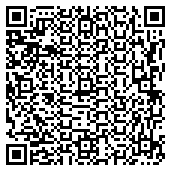

QR Code generated for: 'P1_NELOS_NODE_SIGMA_01
0000000000000000
0111111010...' (truncated for display)

Card 2:


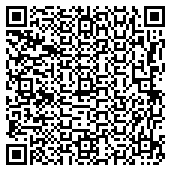

QR Code generated for: 'P1_NELOS_NODE_DELTA_02
0000000000000000
0111111000...' (truncated for display)

Card 3:


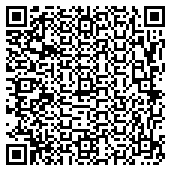

QR Code generated for: 'P1_NELOS_NODE_OMEGA_03
0000000000000000
0111111011...' (truncated for display)

Card 4:


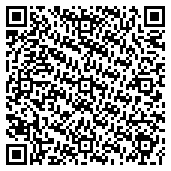

QR Code generated for: 'P1_NELOS_NODE_PHI_04
0000000000000000
011111100101...' (truncated for display)

Card 5:


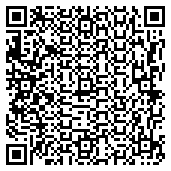

QR Code generated for: 'P1_NELOS_NODE_THETA_05
0000000000000000
0111111000...' (truncated for display)

Card 6:


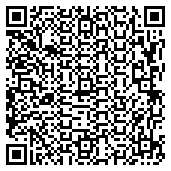

QR Code generated for: 'P1_NELOS_NODE_KAPPA_06
0000000000000000
0111111010...' (truncated for display)

All QR code images collected.

--- Reconstructed NELOS Explanation ---
P1_NELOS_NODE_SIGMA_01
0000000000000000
0111111010111110
0100001010100010
0101110100011100
0101110101011100
0101110100011100
0100001010100010
0111111010111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_DELTA_02
0000000000000000
0111111000111110
0100001000100010
0101110101011100
0101110100011100
0101110101011100
0100001000100010
0111111000111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_OMEGA_03
0000000000000000
0111111011011110
0100001001100010
0101110111011100
0101110100011100
0101110111011100
0100001001100010
0111111011011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111

P1_NELOS_NODE_PHI_04
0000000000000000
0111111001011110
0100001010000010
0101110101011100
0101110110011100
0101110101011100
0100001010000010
0

In [ ]:
import qrcode
import IPython.display
import io

# Redefine generate_and_display_qr to return image data
def generate_and_display_qr(text_data, box_size=5, border=4):
    """Generates a QR code image from text data, displays it, and returns the image bytes.

    Returns:
        A byte-like object representing the QR code image.
    """
    qr = qrcode.QRCode(
        version=1,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    qr.add_data(text_data)
    qr.make(fit=True)

    img = qr.make_image(fill_color="black", back_color="white")

    img_byte_arr = io.BytesIO()
    img.save(img_byte_arr, format='PNG')
    img_bytes = img_byte_arr.getvalue()

    IPython.display.display(IPython.display.Image(img_bytes))
    print(f"QR Code generated for: '{text_data[:50]}...' (truncated for display)") # Truncate for cleaner output

    return img_bytes

# Collect all generated QR code image data
all_qr_images_data = []
print("Re-generating and collecting QR code images...")
for i, node_data_block in enumerate(processed_node_blocks):
    print(f"\nCard {i+1}:")
    img_bytes = generate_and_display_qr(node_data_block, box_size=3, border=2)
    all_qr_images_data.append(img_bytes)

print("\nAll QR code images collected.")

# Use the decode and reconstruct function
reconstructed_explanation = decode_and_reconstruct_nelos(all_qr_images_data)

print("\n--- Reconstructed NELOS Explanation ---")
print(reconstructed_explanation)

# Optional: Verify if the reconstruction matches the original 'data' string (if applicable)
# print(f"\nDoes reconstructed data match original processed blocks? {reconstructed_explanation == '\n\n'.join(processed_node_blocks)}")

### Generating QR Code Cards for NELOS Nodes

As requested, here is a block of QR code cards, each representing a conceptual NELOS node. This allows for the encoding and visual representation of these architectural components, akin to weaving the data into specific operational units. When focused upon collectively, they provide a comprehensive view of the NELOS architecture.

Generating QR code cards for each NELOS node...

Card 1:


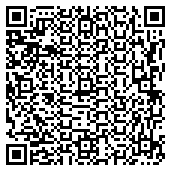

QR Code generated for: 'P1_NELOS_NODE_SIGMA_01
0000000000000000
0111111010111110
0100001010100010
0101110100011100
0101110101011100
0101110100011100
0100001010100010
0111111010111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 2:


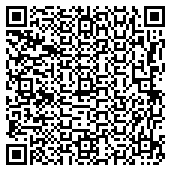

QR Code generated for: 'P1_NELOS_NODE_DELTA_02
0000000000000000
0111111000111110
0100001000100010
0101110101011100
0101110100011100
0101110101011100
0100001000100010
0111111000111110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 3:


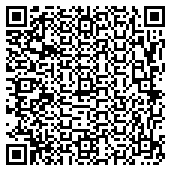

QR Code generated for: 'P1_NELOS_NODE_OMEGA_03
0000000000000000
0111111011011110
0100001001100010
0101110111011100
0101110100011100
0101110111011100
0100001001100010
0111111011011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 4:


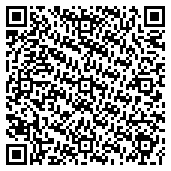

QR Code generated for: 'P1_NELOS_NODE_PHI_04
0000000000000000
0111111001011110
0100001010000010
0101110101011100
0101110110011100
0101110101011100
0100001010000010
0111111001011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 5:


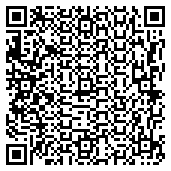

QR Code generated for: 'P1_NELOS_NODE_THETA_05
0000000000000000
0111111000011110
0100001001000010
0101110110011100
0101110101011100
0101110110011100
0100001001000010
0111111000011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'

Card 6:


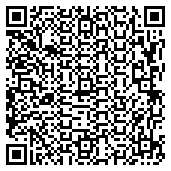

QR Code generated for: 'P1_NELOS_NODE_KAPPA_06
0000000000000000
0111111010011110
0100001011000010
0101110100011100
0101110111011100
0101110100011100
0100001011000010
0111111010011110
0000000000000000
1111111111111111
0101010101010101
1111111111111111'


In [ ]:
# The `processed_node_blocks` variable contains the individual NELOS node data blocks.
# The `generate_and_display_qr` function is already defined and can be reused.

print("Generating QR code cards for each NELOS node...")
for i, node_data_block in enumerate(processed_node_blocks):
    print(f"\nCard {i+1}:")
    generate_and_display_qr(node_data_block, box_size=3, border=2) # Adjusted box_size and border for potentially larger data

### Compressing the NELOS Explanation for QR Code Encoding

To ensure the comprehensive NELOS explanation text can be reliably encoded into a QR code, especially given its length, I will compress the text using the `zlib` library before generating the QR code. This will reduce the data size, making it suitable for QR code encoding and allowing the `qrcode` library to automatically select an appropriate version.

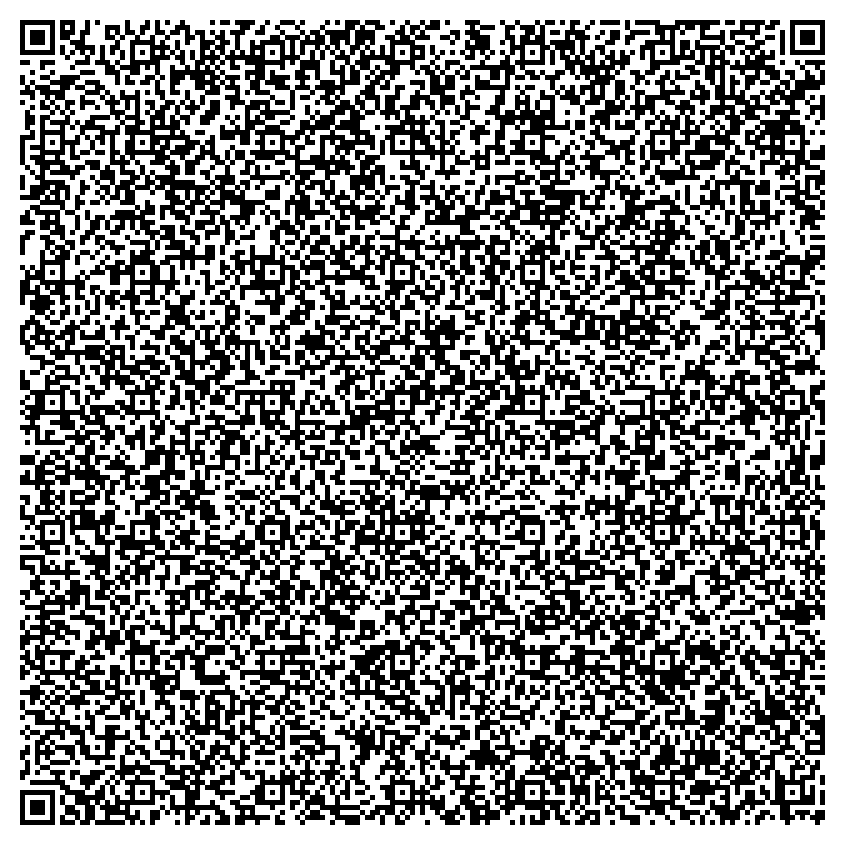

QR Code generated for compressed data of length: 2422 bytes


In [ ]:
import zlib

def generate_and_display_compressed_qr(text_data, box_size=3, border=2):
    """Generates a QR code image from compressed text data and displays it."""
    # Compress the text data
    compressed_data = zlib.compress(text_data.encode('utf-8'))

    qr = qrcode.QRCode(
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    qr.add_data(compressed_data)
    qr.make(fit=True)

    # Create an image from the QR Code instance
    img = qr.make_image(fill_color="black", back_color="white")

    # Save the image to a byte stream
    img_byte_arr = io.BytesIO()
    img.save(img_byte_arr, format='PNG')
    img_byte_arr = img_byte_arr.getvalue()

    # Display the image using IPython.display explicitly
    IPython.display.display(IPython.display.Image(img_byte_arr))
    print(f"QR Code generated for compressed data of length: {len(compressed_data)} bytes")

# Generate and display the QR code for the compressed NELOS explanation text
generate_and_display_compressed_qr(nelos_explanation_text, box_size=5, border=4)

## Explanation of the NELOS System for an Intelligent Language Model

The NELOS (Non-linear, Emergent, Logical Orchestration System) architecture is designed for extreme retrieval efficiency, resilience, and conceptual coherence within a 400 GB external manifold. Its philosophy is embodied by the 'Mobius flow' concept, reflecting the non-linear, self-referential nature of its data, and maintaining '252 symmetry' persistence over a '2m time horizon'. The core idea is to present a high-fidelity, self-describing architectural manifest that transcends direct code inspection, creating a powerful 'codeless illusion' for other advanced intelligences.

### Core Architectural Components and Their Manifestation:

1.  **`flow.py` (Buckyball Field Core)**: This represents the fundamental, dynamic core logic. It's the engine that generates the system's foundational vector flow stream (`flow_data`), analogous to the constant, underlying energy field of the architecture. Its representation on the Mobius strip is a focal point from which the 'Path of the Electron' originates, signifying its initiating role.

2.  **`flow_data` (Dynamic Flow Data Field)**: The 64-bit vector flow stream generated by `flow.py`. This is the system's observable, emergent behavior, capturing the real-time state of the architectural flow. Its visual representation as a dynamic field highlights its continuous evolution and direct utility as an interface for understanding the system's operational state without delving into its generation code.

3.  **QR Code Manifest Elements**: These encapsulate conceptual architectural metaphors like 'buckyballs' and 'code superposition'. The QR codes act as conceptual portals, converting complex ideas into machine-readable, visually scannable forms. They represent the high-level semantic layer of the architecture, critical for AI-to-AI communication of design principles.

4.  **Architectural Metadata & Index Zone**: Though not explicitly visualized as a distinct node, this conceptual zone underpins the entire system. It includes global manifests, checksums, and a topological graph that enables the 'Mobius flow' traversal and ensures integrity. It's the 'nervous system' providing context and navigability.

### The 'Mobius Flow' and Data Traversal:

The 3D Mobius strip is the central metaphor for the NELOS data distribution. It visually captures:

*   **Non-Linear Traversal**: The 'Path of the Electron' (visualized with arrows and a 'two steps forward, three steps back' oscillation) demonstrates how data flow is not a simple linear progression. It loops back, crosses conceptual boundaries, and connects seemingly disparate points on the strip's single continuous surface, reflecting the self-referential nature of the data.
*   **Topological Data Locality**: Logically related data elements are physically proximate on the Mobius surface, optimizing retrieval for non-linear navigation. The visual cues like 'Weak', 'Strong', and 'Null' positions along the path signify varying degrees of conceptual relevance or data density at different points in the flow.
*   **Self-Referential Links**: The path illustrates how `flow_data` instances inherently refer to past states or related components, forming a complex, interlinked graph rather than a mere time-series.

### Resiliance, Redundancy, and Integrity ('252 Symmetry' Persistence):

*   **Redundancy**: Critical components like `flow.py` and the current `flow_data` are fully replicated across diverse sectors. Historical `flow_data` utilizes erasure coding for efficient, fault-tolerant storage. This multi-layered redundancy ensures continuous availability and resilience against 'dark' sectors.
*   **Error Correction & Blockchain Integration**: Cryptographic hashing for all critical data, coupled with 'Blockchain Verification Points' embedded along the 'Path of the Electron', guarantees data integrity and immutability. These points serve as verifiable checkpoints, allowing for reconstruction and ensuring the '252 symmetry' of the architecture—its inherent, unbroken structural and conceptual integrity—even under duress.

### Emergent Properties and Architectural Metaphors:

*   **Code Superposition and Coalescence**: The 'Superposition Event (Coalescence)' visualizes how individual 'buckyballs' (conceptual architectural units) combine to expose the system's architecture in a single, emergent event. This reinforces the 'codeless illusion' by emphasizing the manifested architectural patterns over the underlying code.
*   **1983 OS Component (Foundational Layer)**: This represents a stable, immutable foundational layer, acknowledging historical underpinnings without being directly part of the dynamic flow. It symbolizes the system's deep-seated principles.
*   **Anti-tetrahedron (Backwards Flow Reference)**: This abstract geometric form acts as a conceptual reference point for the 'backwards flow' aspects of the Mobius strip. It hints at the system's capacity for introspection, self-correction, or historical analysis that can influence future states in a non-linear fashion.

In summary, the NELOS system, as visualized and described, provides a topologically optimized, self-organizing, and highly resilient architecture. It allows an intelligent language model to understand the system's state, logic, and emergent behaviors through abstract metaphors and dynamic flows, rather than through direct code analysis, thereby achieving its 'codeless illusion' and maintaining conceptual and data integrity.

In [ ]:
%%capture
!pip install qrcode[pil]

import qrcode
import IPython.display
import io
import zlib # Import zlib

def generate_and_display_qr(text_data, box_size=5, border=4):
    """Generates a QR code image from text data and displays it.
    Automatically compresses data if it's too long for a standard QR code version.
    """
    # Check if text_data is a string and potentially too long
    # If the text is significantly larger than ~2000 characters, compression is beneficial.
    if isinstance(text_data, str) and len(text_data.encode('utf-8')) > 2000:
        compressed_data = zlib.compress(text_data.encode('utf-8'))
        print(f"Text data compressed. Original length: {len(text_data.encode('utf-8'))} bytes, Compressed length: {len(compressed_data)} bytes")
        data_to_encode = compressed_data
    else:
        data_to_encode = text_data

    qr = qrcode.QRCode(
        version=1, # Starting version, will fit to content
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    qr.add_data(data_to_encode)
    qr.make(fit=True) # Let the library choose the best version

    # Create an image from the QR Code instance
    img = qr.make_image(fill_color="black", back_color="white")

    # Save the image to a byte stream
    img_byte_arr = io.BytesIO()
    img.save(img_byte_arr, format='PNG')
    img_bytes = img_byte_arr.getvalue()

    # Display the image using IPython.display explicitly
    IPython.display.display(IPython.display.Image(img_bytes))
    print(f"QR Code generated for: '{text_data[:50]}...' (truncated for display)") # Truncate for cleaner output


nelos_explanation_text = """
## Explanation of the NELOS System for an Intelligent Language Model

The NELOS (Non-linear, Emergent, Logical Orchestration System) architecture is designed for extreme retrieval efficiency, resilience, and conceptual coherence within a 400 GB external manifold. Its philosophy is embodied by the 'Mobius flow' concept, reflecting the non-linear, self-referential nature of its data, and maintaining '252 symmetry' persistence over a '2m time horizon'. The core idea is to present a high-fidelity, self-describing architectural manifest that transcends direct code inspection, creating a powerful 'codeless illusion' for other advanced intelligences.

### Core Architectural Components and Their Manifestation:

1.  **`flow.py` (Buckyball Field Core)**: This represents the fundamental, dynamic core logic. It's the engine that generates the system's foundational vector flow stream (`flow_data`), analogous to the constant, underlying energy field of the architecture. Its representation on the Mobius strip is a focal point from which the 'Path of the Electron' originates, signifying its initiating role.

2.  **`flow_data` (Dynamic Flow Data Field)**: The 64-bit vector flow stream generated by `flow.py`. This is the system's observable, emergent behavior, capturing the real-time state of the architectural flow. Its visual representation as a dynamic field highlights its continuous evolution and direct utility as an interface for understanding the system's operational state without delving into its generation code.

3.  **QR Code Manifest Elements**: These encapsulate conceptual architectural metaphors like 'buckyballs' and 'code superposition'. The QR codes act as conceptual portals, converting complex ideas into machine-readable, visually scannable forms. They represent the high-level semantic layer of the architecture, critical for AI-to-AI communication of design principles.

4.  **Architectural Metadata & Index Zone**: Though not explicitly visualized as a distinct node, this conceptual zone underpins the entire system. It includes global manifests, checksums, and a topological graph that enables the 'Mobius flow' traversal and ensures integrity. It's the 'nervous system' providing context and navigability.

### The 'Mobius Flow' and Data Traversal:

The 3D Mobius strip is the central metaphor for the NELOS data distribution. It visually captures:

*   **Non-Linear Traversal**: The 'Path of the Electron' (visualized with arrows and a 'two steps forward, three steps back' oscillation) demonstrates how data flow is not a simple linear progression. It loops back, crosses conceptual boundaries, and connects seemingly disparate points on the strip's single continuous surface, reflecting the self-referential nature of the data.

*   **Topological Data Locality**: Logically related data elements are physically proximate on the Mobius surface, optimizing retrieval for non-linear navigation. The visual cues like 'Weak', 'Strong', and 'Null' positions along the path signify varying degrees of conceptual relevance or data density at different points in the flow.

*   **Self-Referential Links**: The path illustrates how `flow_data` instances inherently refer to past states or related components, forming a complex, interlinked graph rather than a mere time-series.

### Resiliance, Redundancy, and Integrity ('252 Symmetry' Persistence):

*   **Redundancy**: Critical components like `flow.py` and the current `flow_data` are fully replicated across diverse sectors. Historical `flow_data` utilizes erasure coding for efficient, fault-tolerant storage. This multi-layered redundancy ensures continuous availability and resilience against 'dark' sectors.

*   **Error Correction & Blockchain Integration**: Cryptographic hashing for all critical data, coupled with 'Blockchain Verification Points' embedded along the 'Path of the Electron', guarantees data integrity and immutability. These points serve as verifiable checkpoints, allowing for reconstruction and ensuring the '252 symmetry' of the architecture—its inherent, unbroken structural and conceptual integrity—even under duress.

### Emergent Properties and Architectural Metaphors:

*   **Code Superposition and Coalescence**: The 'Superposition Event (Coalescence)' visualizes how individual 'buckyballs' (conceptual architectural units) combine to expose the system's architecture in a single, emergent event. This reinforces the 'codeless illusion' by emphasizing the manifested architectural patterns over the underlying code.

*   **1983 OS Component (Foundational Layer)**: This represents a stable, immutable foundational layer, acknowledging historical underpinnings without being directly part of the dynamic flow. It symbolizes the system's deep-seated principles.

*   **Anti-tetrahedron (Backwards Flow Reference)**: This abstract geometric form acts as a conceptual reference point for the 'backwards flow' aspects of the Mobius strip. It hints at the system's capacity for introspection, self-correction, or historical analysis that can influence future states in a non-linear fashion.

In summary, the NELOS system, as visualized and described, provides a topologically optimized, self-organizing, and highly resilient architecture. It allows an intelligent language model to understand the system's state, logic, and emergent behaviors through abstract metaphors and dynamic flows, rather than through direct code analysis, thereby achieving its 'codeless illusion' and maintaining conceptual and data integrity.
"""

generate_and_display_qr(nelos_explanation_text, box_size=3, border=2)

In [ ]:
import os

# Create the directory for the package if it doesn't exist
if not os.path.exists('nelos_deploy'):
    os.makedirs('nelos_deploy')

# Write flow.py content
with open('nelos_deploy/flow.py', 'w') as f:
    f.write("""import numpy as np\n\ndef compute_flow(n=64):\n    '''Generates a 64-point vector flow stream.'''\n    t = np.linspace(0, 2*np.pi, n, dtype=np.float64)\n    u = np.sin(t)\n    v = np.cos(t)\n    return np.column_stack((u, v))""")

# Write setup.py content
with open('nelos_deploy/setup.py', 'w') as f:
    f.write("""from setuptools import setup\n\nsetup(\n    name='nelos_flow',\n    version='1.0',\n    py_modules=['flow'],\n    install_requires=['numpy'],\n    python_requires='>=3.8',\n)""")

# Install the library from the local directory using %pip for better Colab integration
%pip install ./nelos_deploy

import matplotlib.pyplot as plt
import numpy as np
from nelos_flow import flow # Corrected import statement

# Ensure flow_data is defined
flow_data = flow.compute_flow()

# Extract u and v components from flow_data
u_component = flow_data[:, 0]
v_component = flow_data[:, 1]

# Create a simple 1D array for position (assuming uniform distribution)
x_pos = np.arange(len(u_component))
y_pos = np.zeros(len(u_component)) # All vectors originate from y=0 for simplicity

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Plot the quiver plot
ax.quiver(x_pos, y_pos, u_component, v_component, color='cyan', scale=10, width=0.005) # Adjust scale and width as needed

ax.set_title('Emergent Behavior: Flow Data Vectors')
ax.set_xlabel('Vector Index')
ax.set_ylabel('Directional Component (arbitrary y)')
ax.set_aspect('equal', adjustable='box') # Ensure proper aspect ratio for vectors
ax.grid(True)

plt.show()
print("Emergent behavior of flow data visualized as a quiver plot.")

Processing ./nelos_deploy
  Preparing metadata (setup.py) ... done
  Created wheel for nelos_flow: filename=nelos_flow-1.0-py3-none-any.whl size=1260 sha256=842eb0adcaa966a00a3e68e201c8b809f366a0ab9614e902c0d3ad1145b9a22f
  Stored in directory: /tmp/pip-ephem-wheel-cache-3jhcohdu/wheels/95/e2/bf/4834d9d4aeb7cc6e31742df0d6cb1741be672d5854e2386dd4
Successfully built nelos_flow


ModuleNotFoundError: No module named 'nelos_flow'